In [ ]:
# Loading Dataset
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [ ]:
!unzip '/content/drive/MyDrive/SERDATABASES/IMBD.zip'

Archive:  /content/drive/MyDrive/SERDATABASES/IMBD.zip
  inflating: IMDB Dataset.csv        


# Databases Analysis

In [ ]:
import re
import pandas as pd
import tensorflow as tf
import numpy as np  # linear algebra

# Load datasets
Gutenberg = pd.read_csv(
    "/content/drive/MyDrive/SERDATABASES/poem-sentiment-Gutenberg/data/train.tsv",
    sep='\t',
    names=["Text", "Emotion"],
    encoding='utf-8'
)

IMDB = pd.read_csv(
    "/content/IMDB Dataset.csv",
    sep=",",
    names=["Text", "Emotion"],
    encoding='utf-8'
)

# Filter and clean Emotion labels in Gutenberg
Gutenberg = Gutenberg[Gutenberg["Emotion"].isin([-1, 1])].copy()
Gutenberg["Emotion"] = Gutenberg["Emotion"].replace({-1: 0, 1: 1})

# Drop header row from IMDB dataset
IMDB = IMDB.drop(IMDB.index[0])
IMDB["Emotion"] = IMDB["Emotion"].replace({"negative": 0, "positive": 1}).astype(int)

# Optimized preprocessing function
def preprocess(df, text_column='Text'):
    df = df.copy()  # Ensure we're working on a copy
    df[text_column] = df[text_column].replace(regex=['<br />', '\n'], value=' ')

    def clean_text(text):
        if not isinstance(text, str):
            return ''
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)  # Remove punctuation/special characters
        text = re.sub(r'\s+', ' ', text).strip()  # Normalize whitespace
        return text

    df[text_column] = df[text_column].apply(clean_text)
    return df

# Apply preprocessing
Gutenberg = preprocess(Gutenberg)
IMDB = preprocess(IMDB)

# Combine both datasets
Combined = pd.concat([Gutenberg, IMDB], ignore_index=True)

# Show output previews
print(Gutenberg.head())
print(IMDB.head())
print(Combined.head())
print("Total combined samples:", Combined.shape[0])


<ipython-input-31-8319af24c57c>:27: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  IMDB["Emotion"] = IMDB["Emotion"].replace({"negative": 0, "positive": 1}).astype(int)


                                               Text  Emotion
0   with pale blue berries in these peaceful shades        1
2                  and that is why the lonesome day        0
8            and so on then a worthless gaud or two        0
16                that has a charmingly bourbon air        1
17       sounded oer earth and sea its blast of war        0
                                                Text  Emotion
1  one of the other reviewers has mentioned that ...        1
2  a wonderful little production the filming tech...        1
3  i thought this was a wonderful way to spend ti...        1
4  basically theres a family where a little boy j...        0
5  petter matteis love in the time of money is a ...        1
                                              Text  Emotion
0  with pale blue berries in these peaceful shades        1
1                 and that is why the lonesome day        0
2           and so on then a worthless gaud or two        0
3                that 

In [ ]:

import spacy
from collections import Counter

# Load spaCy English model (disable NER and parser for speed)
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def Lemma_and_filter_text(df, text_column='Text', min_word_length=2, min_freq=0, custom_stopwords=None):
    # Combine stopwords
    spacy_stopwords = spacy.lang.en.stop_words.STOP_WORDS
    combined_stopwords = spacy_stopwords.union(custom_stopwords or set())

    # Ensure text is string and not null
    df[text_column] = df[text_column].astype(str).fillna('')

    # Process texts with spaCy
    docs = list(nlp.pipe(df[text_column].tolist(), batch_size=32))

    # Lemmatize and clean
    cleaned_texts = []
    for doc in docs:
        tokens = [
            token.lemma_.lower()
            for token in doc
            if token.is_alpha and
               token.lemma_.lower() not in combined_stopwords and
               len(token.lemma_) >= min_word_length
        ]
        cleaned_texts.append(" ".join(tokens))

    # Add cleaned column temporarily
    df['Text'] = cleaned_texts

    # Compute word frequencies
    all_words = " ".join(df['Text']).split()
    word_freq = Counter(all_words)
    frequent_words = {word for word, count in word_freq.items() if count >= min_freq}

    # Filter tokens by frequency
    df['Text'] = df['Text'].apply(
        lambda text: " ".join([word for word in text.split() if word in frequent_words])
    )

    # Return only cleaned text and label
    return df[['Text', 'Emotion']]


In [ ]:
Gutenberg_Lemma = Lemma_and_filter_text(Gutenberg, text_column='Text', min_word_length=2, min_freq=1)
IMDB_Lemma = Lemma_and_filter_text(IMDB, text_column='Text', min_word_length=2, min_freq=6)
#Combined_Lemma = Lemma_and_filter_text(Combined, text_column='Text', min_word_length=2, min_freq=3)


In [ ]:
Combined_Lemma = pd.concat([Gutenberg_Lemma, IMDB_Lemma], ignore_index=True)


In [ ]:
# Show output previews
print(Gutenberg_Lemma.head())
print(IMDB_Lemma.head())
print(Combined_Lemma.head())
print("Total combined samples:", Combined_Lemma.shape[0])


                              Text  Emotion
0   pale blue berry peaceful shade        1
2                     lonesome day        0
8                   worthless gaud        0
16          charmingly bourbon air        1
17   sound oer earth sea blast war        0
                                                Text  Emotion
1  reviewer mention watch oz episode ll hook righ...        1
2  wonderful little production filming technique ...        1
3  think wonderful way spend time hot summer week...        1
4  basically family little boy jake think zombie ...        0
5  matteis love time money visually stunning film...        1
                             Text  Emotion
0  pale blue berry peaceful shade        1
1                    lonesome day        0
2                  worthless gaud        0
3          charmingly bourbon air        1
4   sound oer earth sea blast war        0
Total combined samples: 50243


In [ ]:
# Count class distribution in Gutenberg dataset
print("Gutenberg Train class distribution:\n", Gutenberg["Emotion"].value_counts())

# Count class distribution in IMDB dataset
print("IMDB class distribution:\n", IMDB["Emotion"].value_counts())

# Count class distribution in the combined dataset
print("Combined dataset class distribution:\n", Combined["Emotion"].value_counts())

Gutenberg Train class distribution:
 Emotion
0    130
1    113
Name: count, dtype: int64
IMDB class distribution:
 Emotion
1    25000
0    25000
Name: count, dtype: int64
Combined dataset class distribution:
 Emotion
0    25130
1    25113
Name: count, dtype: int64


## Database Gutenberg

In [ ]:
Gutenberg.head(10)

,Text,Emotion,text_length,text_word_count
0,with pale blue berries in these peaceful shades,1,47,8
2,and that is why the lonesome day,0,32,7
8,and so on then a worthless gaud or two,0,38,9
16,that has a charmingly bourbon air,1,33,6
17,sounded oer earth and sea its blast of war,0,42,9
20,brightly expressive as the twins of leda,1,40,7
23,in monumental pomp no grecian drop,1,34,6
37,want and woe which torture us,0,29,6
39,an echo returned on the cold gray morn,0,38,8
41,while i i built up follies like a wall,0,38,9


In [ ]:
Gutenberg_Lemma.head(10)

,Text,Emotion,text_length,text_word_count
0,pale blue berry peaceful shade,1,30,5
2,lonesome day,0,12,2
8,worthless gaud,0,14,2
16,charmingly bourbon air,1,22,3
17,sound oer earth sea blast war,0,29,6
20,brightly expressive twin leda,1,29,4
23,monumental pomp grecian drop,1,28,4
37,want woe torture,0,16,3
39,echo return cold gray morn,0,26,5
41,build folly like wall,0,21,4


In [ ]:
# Combine the two datasets side-by-side
Compare = pd.DataFrame({
    'Original_Text': Gutenberg['Text'],
    'Lemmatized_Text': Gutenberg_Lemma['Text'],
    'Emotion': Gutenberg['Emotion']  # or Gutenberg_Lemma['Emotion'], should be identical
})

# Display the combined table
Compare

,Original_Text,Lemmatized_Text,Emotion
0,with pale blue berries in these peaceful shades,pale blue berry peaceful shade,1
2,and that is why the lonesome day,lonesome day,0
8,and so on then a worthless gaud or two,worthless gaud,0
16,that has a charmingly bourbon air,charmingly bourbon air,1
17,sounded oer earth and sea its blast of war,sound oer earth sea blast war,0
...,...,...,...
883,by deaths frequented ways,death frequent way,0
885,rejection of his humanness,rejection humanness,0
888,the one good man in the world who knows me,good man world know,1
889,faint voices lifted shrill with pain,faint voice lift shrill pain,0


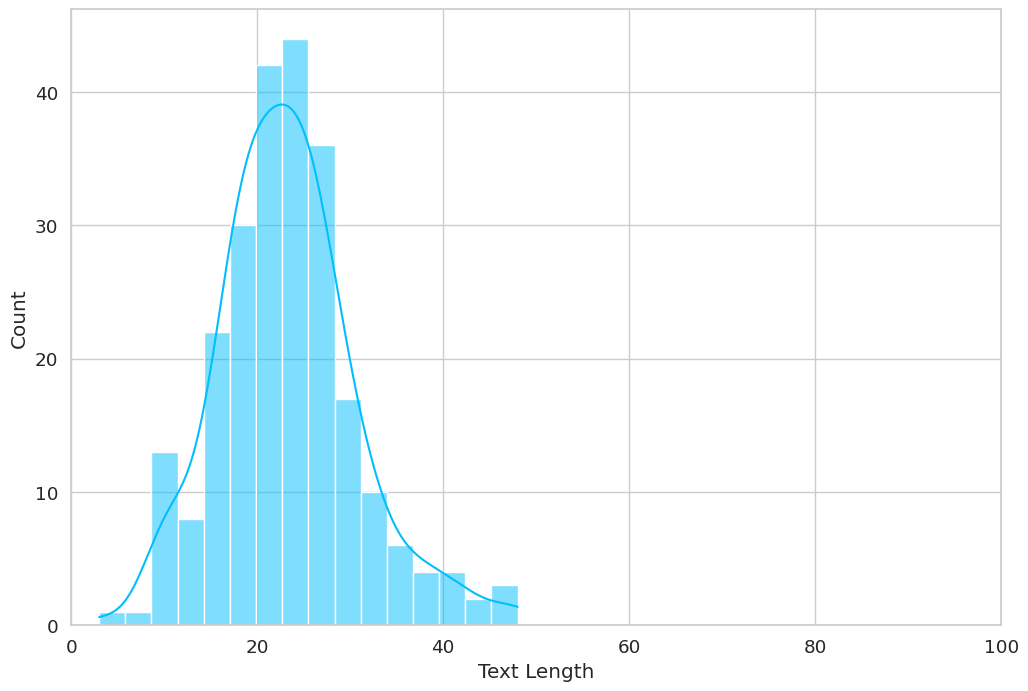

In [ ]:
import numpy as np
import pandas as pd
import string

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
colors = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(colors))
matplotlib.rcParams['figure.figsize'] = 12, 8

Gutenberg['text_length'] = Gutenberg['Text'].astype(str).apply(len)
Gutenberg['text_word_count'] = Gutenberg['Text'].apply(lambda x: len(str(x).split()))

sns.histplot(Gutenberg['text_length'], kde=True)

plt.xlim([0, 100]);
plt.xlabel('Text Length');

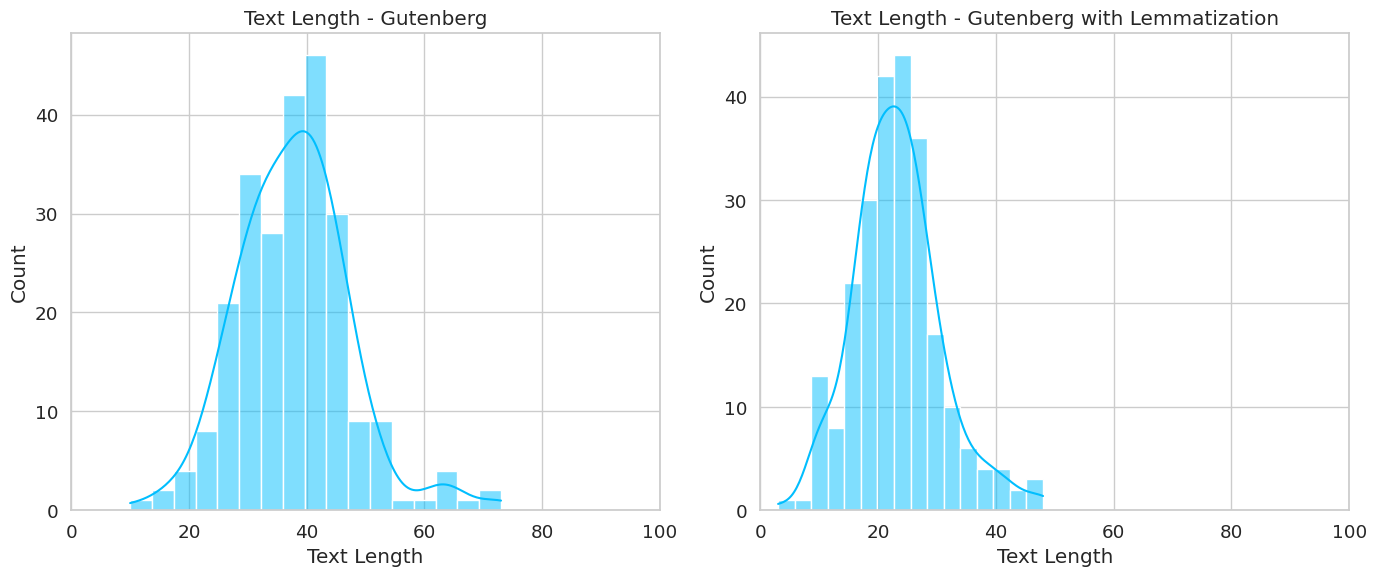

In [ ]:
import numpy as np
import pandas as pd
import string

import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Style setup
sns.set(style='whitegrid', palette='muted', font_scale=1.2)
colors = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(colors))
matplotlib.rcParams['figure.figsize'] = 12, 6

# Assuming Gutenberg and Gutenberg_Lemma DataFrames are defined

# Calculate text length and word count for both datasets
Gutenberg['text_length'] = Gutenberg['Text'].astype(str).apply(len)
Gutenberg['text_word_count'] = Gutenberg['Text'].apply(lambda x: len(str(x).split()))

Gutenberg_Lemma['text_length'] = Gutenberg_Lemma['Text'].astype(str).apply(len)
Gutenberg_Lemma['text_word_count'] = Gutenberg_Lemma['Text'].apply(lambda x: len(str(x).split()))

# Create two subplots in a single row
fig, axes = plt.subplots(ncols=2, figsize=(14, 6))

# Plot for Gutenberg
sns.histplot(Gutenberg['text_length'], kde=True, ax=axes[0])
axes[0].set_xlim([0, 100])
axes[0].set_xlabel('Text Length')
axes[0].set_title('Gutenberg')

# Plot for Gutenberg_Lemma
sns.histplot(Gutenberg_Lemma['text_length'], kde=True, ax=axes[1])
axes[1].set_xlim([0, 100])
axes[1].set_xlabel('Text Length')
axes[1].set_title('Gutenberg Lemma')

plt.tight_layout()
plt.show()


Emotion
0    3.900000
1    3.787611
Name: text_word_count, dtype: float64


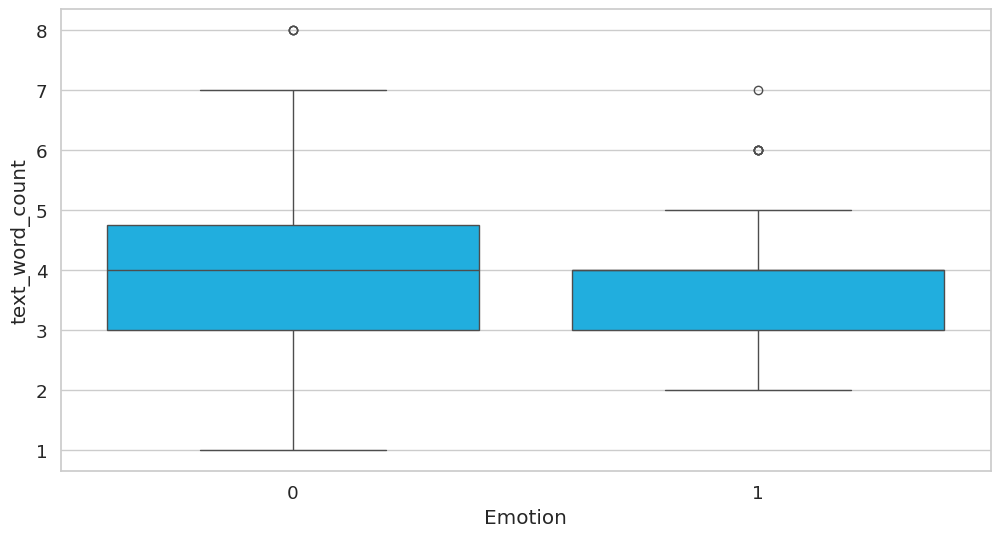

In [ ]:
sns.boxplot(x="Emotion", y="text_word_count", data=Gutenberg)

mean_word_count_by_label = Gutenberg.groupby('Emotion')['text_word_count'].mean()
print(mean_word_count_by_label)

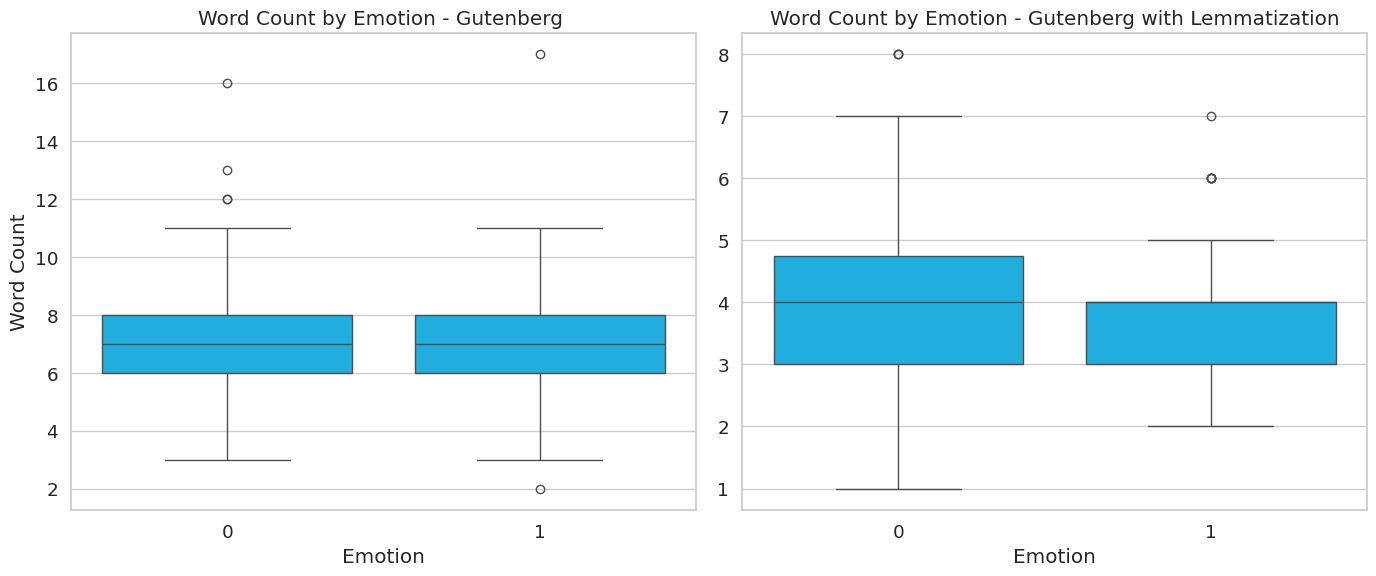

In [ ]:
# Boxplot comparison of word count by emotion
fig, axes = plt.subplots(ncols=2, figsize=(14, 6))

# Gutenberg boxplot
sns.boxplot(x="Emotion", y="text_word_count", data=Gutenberg, ax=axes[0])
axes[0].set_title("Gutenberg - Word Count by Emotion")
axes[0].set_xlabel("Emotion")
axes[0].set_ylabel("Word Count")

# Gutenberg_Lemma boxplot
sns.boxplot(x="Emotion", y="text_word_count", data=Gutenberg_Lemma, ax=axes[1])
axes[1].set_title("Gutenberg Lemma - Word Count by Emotion")
axes[1].set_xlabel("Emotion")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

In [ ]:
# Calculate the number of unique words in the original 'text' column (before cleaning)
all_original_words = " ".join(df['Text']).split()
unique_original_words = set(all_original_words)

# Extract all words from the 'cleaned_lyrics' column and find the unique ones
all_cleaned_words = " ".join(df['cleaned_lyrics']).split()
unique_cleaned_words = set(all_cleaned_words)

# Count the frequency of each unigram
unigram_counts = Counter(tokens)

# Get the 20 most common unigrams
most_common_unigrams = unigram_counts.most_common(20)

# Separate the unigrams and their counts for visualization
unigrams, counts = zip(*most_common_unigrams)

# Create a bar plot
plt.figure(figsize=(12, 6))
plt.bar(unigrams, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('20 Most Frequent Unigrams in Lyrics')
plt.xlabel('Unigrams')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Display the number of unique words
print(f"Number of unique words in original text: {len(unique_original_words)}")
print(f"Number of unique words in cleaned lyrics: {len(unique_cleaned_words)}")

# Display the cleaned DataFrame
df.head(10)

Total tokens: 1720


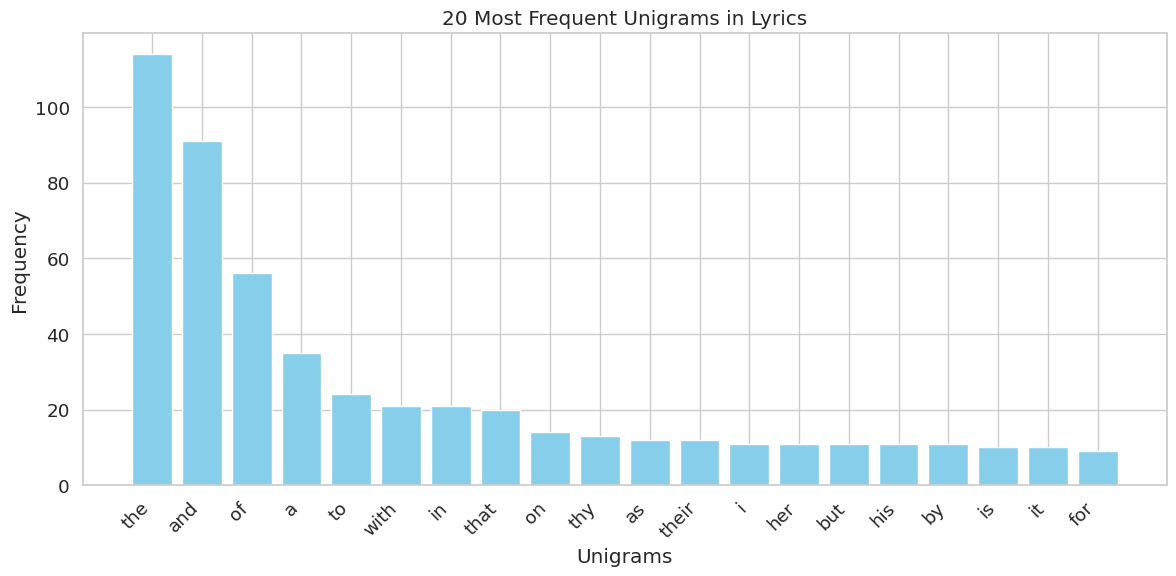

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Combine all the text into a single string
all_text = " ".join(Gutenberg_Train['Text'].astype(str))

# Tokenize the text into unigrams (split by spaces)
tokens = all_text.split()

# Count the total number of tokens
total_tokens = len(tokens)
print("Total tokens:", total_tokens)

# Count the frequency of each unigram
unigram_counts = Counter(tokens)

# Get the 20 most common unigrams
most_common_unigrams = unigram_counts.most_common(20)

# Separate the unigrams and their counts for visualization
unigrams, counts = zip(*most_common_unigrams)

# Create a bar plot
plt.figure(figsize=(12, 6))
plt.bar(unigrams, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('20 Most Frequent Unigrams in Lyrics')
plt.xlabel('Unigrams')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [ ]:
#!pip install nltk spacy
#!python -m spacy download es_core_news_sm
import re
import spacy
from collections import Counter
import nltk
nltk.download('stopwords')

# Load English language model from spaCy
nlp = spacy.load('en_core_web_sm')

# Define the text cleaning function
def clean_and_filter_text(df, text_column='text', min_word_length=3, min_freq=10, custom_stopwords=None):
    # Prepare combined stopword list
    spacy_stopwords = spacy.lang.en.stop_words.STOP_WORDS  # SpaCy's English stopwords
    combined_stopwords = spacy_stopwords.union(custom_stopwords or set())

    def clean_text(text):
        # Ensure input is a string
        if not isinstance(text, str):
            return ''

        # Lowercase, remove punctuation, special characters, and normalize spaces
        text = re.sub(r'[^\w\s]', '', text.lower())  # Remove punctuation and special characters
        text = re.sub(r'\s+', ' ', text).strip()  # Normalize spaces

        # Process with spaCy
        doc = nlp(text)

        # Remove stopwords, short words, and non-alphabetic tokens
        filtered_tokens = [
            token.text for token in doc
            if token.text not in combined_stopwords and len(token.text) >= min_word_length and token.is_alpha
        ]
        return " ".join(filtered_tokens)

    # Clean the text column
    df['cleaned_text'] = df[text_column].apply(clean_text)

    # Calculate word frequencies
    all_words = " ".join(df['cleaned_text']).split()
    word_freq = Counter(all_words)

    # Filter words by minimum frequency
    frequent_words = {word for word, count in word_freq.items() if count >= min_freq}
    df['cleaned_text'] = df['cleaned_text'].apply(
        lambda text: " ".join([word for word in text.split() if word in frequent_words])
    )

    return df


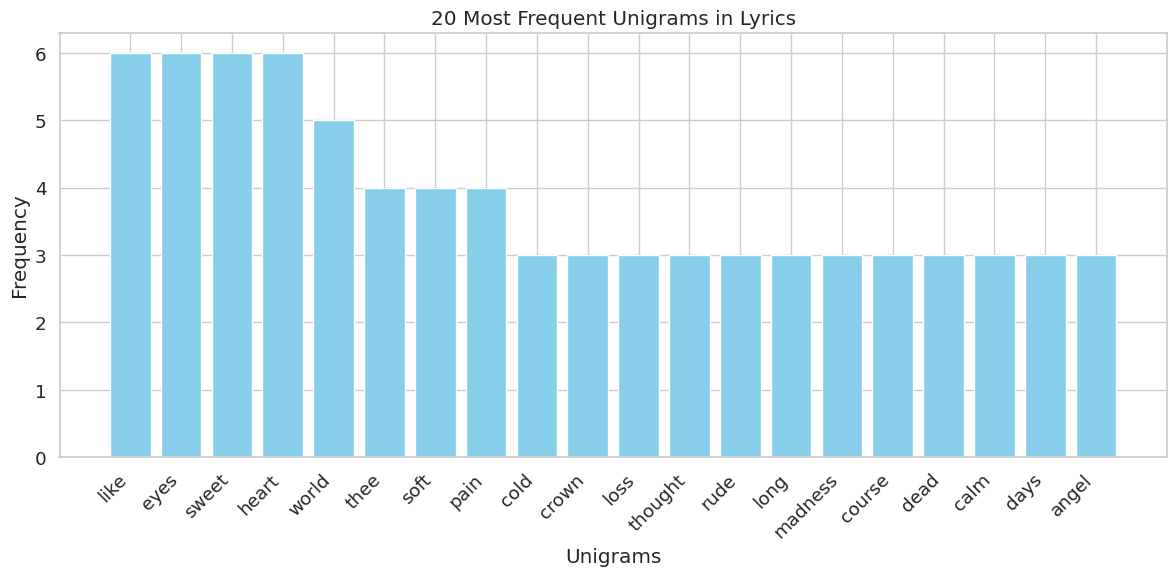

Number of unique words in original text: 882
Number of unique words in cleaned lyrics: 777


,Text,Emotion,text_length,text_word_count,cleaned_lyrics,cleaned_text
0,with pale blue berries in these peaceful shades,1,47,8,with pale blue berries these peaceful shades,pale blue berries peaceful shades
2,and that is why the lonesome day,0,32,7,that lonesome,lonesome
8,and so on then a worthless gaud or two,0,38,9,then worthless gaud,worthless gaud
16,that has a charmingly bourbon air,1,33,6,that charmingly bourbon,charmingly bourbon
17,sounded oer earth and sea its blast of war,0,42,9,sounded earth blast,sounded earth blast
20,brightly expressive as the twins of leda,1,40,7,brightly expressive twins leda,brightly expressive twins leda
23,in monumental pomp no grecian drop,1,34,6,monumental pomp grecian drop,monumental pomp grecian drop
37,want and woe which torture us,0,29,6,want which torture,want torture
39,an echo returned on the cold gray morn,0,38,8,echo returned cold gray morn,echo returned cold gray morn
41,while i i built up follies like a wall,0,39,9,while built follies like wall,built follies like wall


In [ ]:
# Example usage
custom_stopwords = {'lalala', 'nanana', 'yeah', 'oh', 'o', 'pum', 'diu', 'non', 'per', 'tra', 'ay', 'ea', 'murru', 'trebolé', 'patiné', 'ro','do','álimon', 'ra', 'pin', 'pan', 'nea', 'plun', 'ova', 'güi', 'miau'}
# Assuming `df` is already defined as a DataFrame
df = clean_and_filter_text(Gutenberg_Train, text_column='Text', min_word_length=4, min_freq=1, custom_stopwords=custom_stopwords)

# Calculate the number of unique words in the original 'text' column (before cleaning)
all_original_words = " ".join(df['Text']).split()
unique_original_words = set(all_original_words)

# Extract all words from the 'cleaned_lyrics' column and find the unique ones
all_cleaned_words = " ".join(df['cleaned_lyrics']).split()
unique_cleaned_words = set(all_cleaned_words)

# Count the frequency of each unigram
unigram_counts = Counter(tokens)

# Get the 20 most common unigrams
most_common_unigrams = unigram_counts.most_common(20)

# Separate the unigrams and their counts for visualization
unigrams, counts = zip(*most_common_unigrams)

# Create a bar plot
plt.figure(figsize=(12, 6))
plt.bar(unigrams, counts, color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('20 Most Frequent Unigrams in Lyrics')
plt.xlabel('Unigrams')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Display the number of unique words
print(f"Number of unique words in original text: {len(unique_original_words)}")
print(f"Number of unique words in cleaned lyrics: {len(unique_cleaned_words)}")

# Display the cleaned DataFrame
df.head(10)


## IMDB Database

In [ ]:
pd.set_option('display.max_colwidth', None)
IMDB.head(10)

,Text,Emotion
1,one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictures painted for mainstream audiences forget charm forget romanceoz doesnt mess around the first episode i ever saw struck me as so nasty it was surreal i couldnt say i was ready for it but as i watched more i developed a taste for oz and got accustomed to the high levels of graphic violence not just violence but injustice crooked guards wholl be sold out for a nickel inmates wholl kill on order and get away with it well mannered middle class inmates being turned into prison bitches due to their lack of street skills or prison experience watching oz you may become comfortable with what is uncomfortable viewingthats if you can get in touch with your darker side,1
2,a wonderful little production the filming technique is very unassuming very oldtimebbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down pat too you can truly see the seamless editing guided by the references to williams diary entries not only is it well worth the watching but it is a terrificly written and performed piece a masterful production about one of the great masters of comedy and his life the realism really comes home with the little things the fantasy of the guard which rather than use the traditional dream techniques remains solid then disappears it plays on our knowledge and our senses particularly with the scenes concerning orton and halliwell and the sets particularly of their flat with halliwells murals decorating every surface are terribly well done,1
3,i thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air conditioned theater and watching a lighthearted comedy the plot is simplistic but the dialogue is witty and the characters are likable even the well bread suspected serial killer while some may be disappointed when they realize this is not match point 2 risk addiction i thought it was proof that woody allen is still fully in control of the style many of us have grown to love this was the most id laughed at one of woodys comedies in years dare i say a decade while ive never been impressed with scarlet johanson in this she managed to tone down her sexy image and jumped right into a average but spirited young woman this may not be the crown jewel of his career but it was wittier than devil wears prada and more interesting than superman a great comedy to go see with friends,1
4,basically theres a family where a little boy jake thinks theres a zombie in his closet his parents are fighting all the time this movie is slower than a soap opera and suddenly jake decides to become rambo and kill the zombie ok first of all when youre going to make a film you must decide if its a thriller or a drama as a drama the movie is watchable parents are divorcing arguing like in real life and then we have jake with his closet which totally ruins all the film i expected to see

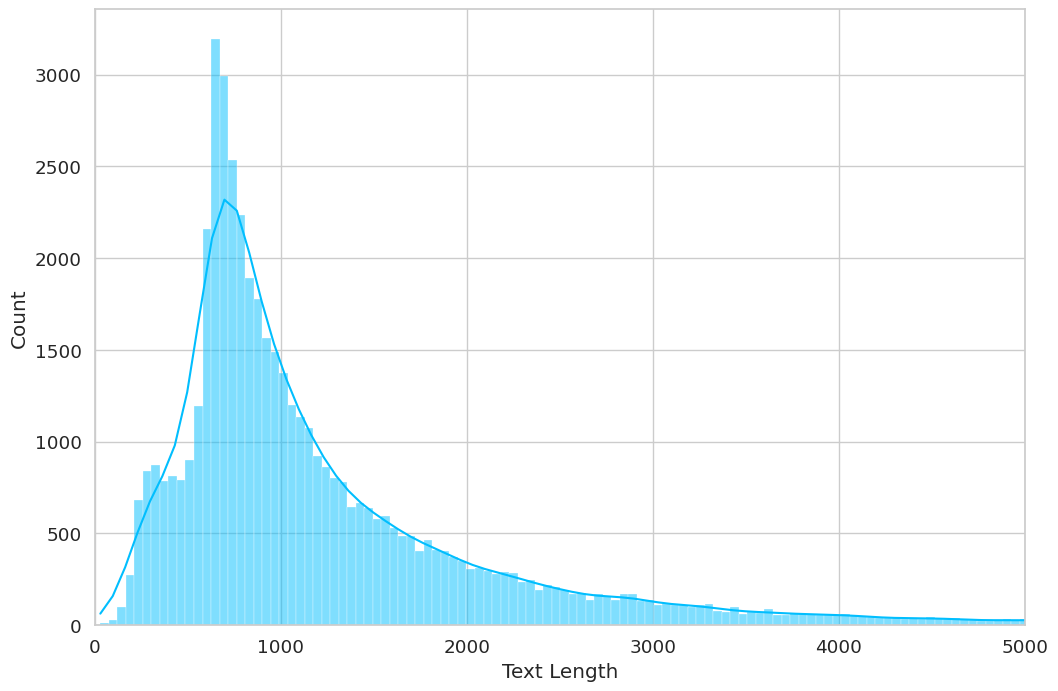

In [ ]:

sns.set(style='whitegrid', palette='muted', font_scale=1.2)
colors = ["#01BEFE", "#FFDD00", "#FF7D00", "#FF006D", "#ADFF02", "#8F00FF"]
sns.set_palette(sns.color_palette(colors))
matplotlib.rcParams['figure.figsize'] = 12, 8

IMDB['text_length'] = IMDB['Text'].astype(str).apply(len)
IMDB['text_word_count'] = IMDB['Text'].apply(lambda x: len(str(x).split()))

sns.histplot(IMDB['text_length'], kde=True)

plt.xlim([0, 5000]);
plt.xlabel('Text Length');

Emotion
0    226.12364
1    229.73128
Name: text_word_count, dtype: float64


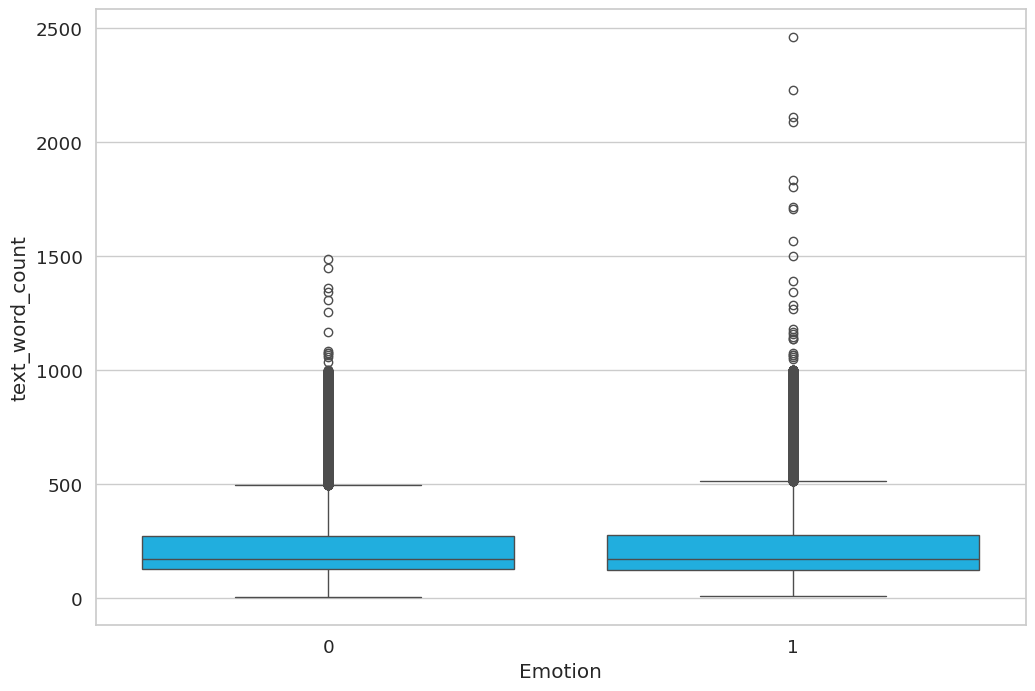

In [ ]:
sns.boxplot(x="Emotion", y="text_word_count", data=IMDB)

mean_word_count_by_label2 = IMDB.groupby('Emotion')['text_word_count'].mean()
print(mean_word_count_by_label2)

In [ ]:
filtered_IMDB = IMDB[IMDB['Text'].apply(lambda x: len(x.split()) <= 100)]
filtered_IMDB

,Text,Emotion,text_length,text_word_count
10,if you like original gut wrenching laughter you will like this movie if you are young or old then you will love this movie hell even my mom liked it great camp,1,160,32
11,phil the alien is one of those quirky films where the humour is based around the oddness of everything rather than actual punchlines at first it was very odd and pretty funny but as the movie progressed i didnt find the jokes or oddness funny anymore its a low budget film thats never a problem in itself there were some pretty interesting characters but eventually i just lost interest i imagine this film would appeal to a stoner who is currently partaking for something similar but better try brother from another planet,0,527,92
15,this a fantastic movie of three prisoners who become famous one of the actors is george clooney and im not a fan but this roll is not bad another good thing about the movie is the soundtrack the man of constant sorrow i recommand this movie to everybody greetings bart,1,268,50
23,what an absolutely stunning movie if you have 25 hrs to kill watch it you wont regret it its too much fun rajnikanth carries the movie on his shoulders and although there isnt anything more other than him i still liked it the music by arrehman takes time to grow on you but after you heard it a few times you really start liking it,1,331,65
37,the plot is about the death of little children hopper is the one who has to investigate the killings during the movie it appears that he has some troubles with his daughter in the end the serial killer get caught thats it but before you find out who dunnit you have to see some terrible acting by all of the actors it is unbelievable how bad these actors are including hopper i could go on like this but that to much of a waste of my time just dont watch the movie ive warned you,0,479,95
...,...,...,...,...
49946,this picture started out with good intentions bacon the scientist out to test the theory of invisibility and shue is cute as usual in her role it all falls apart after that its your typical hollywood thriller now filmed on a soundstage with special effects galore minus any kind of humour wit or soul in other words dont waste your time watching this get the audiocassette tape with john delancie as the invisible man instead also starring leonard nimoy now that was good and hg wells is well served unlike with this mess,0,521,93
49956,i have not seen this movie but i must having read all three of thor heyerdahls books kon tiki ra and aku aku i am actively looking for a copy of this movie the thesis that peruvians migrated to polynesia is alive and well considering that this crew had no gps and only an old fashioned valve tube radio with a 6watt output their voyage was heroic to say the least please reply to this message if you can tell me the location of a copy of this video i would be interested in buying it,1,486,96
49964,if you like really shocking movies this is for you the acting is the worst ive ever seen and the story line goes nowhere if you come across this film in your video shop dont even consider borrowing it the chick on the front cover isnt even the one in the moviei gave this movie 110 only because i couldnt vote 0 avoid it at all costs,0,333,67
49969,i must say as a girl with a cowboy of my owni love this flickit left me lovin them boots and wranglers even morei told my friend about it and she loved it just as muchwe were bout 13 at the timei think its the greatest love story ever toldi own it and never get tired of bud sissy,1,281,59


Emotion
0    10.166667
1    13.875000
Name: text_word_count, dtype: float64


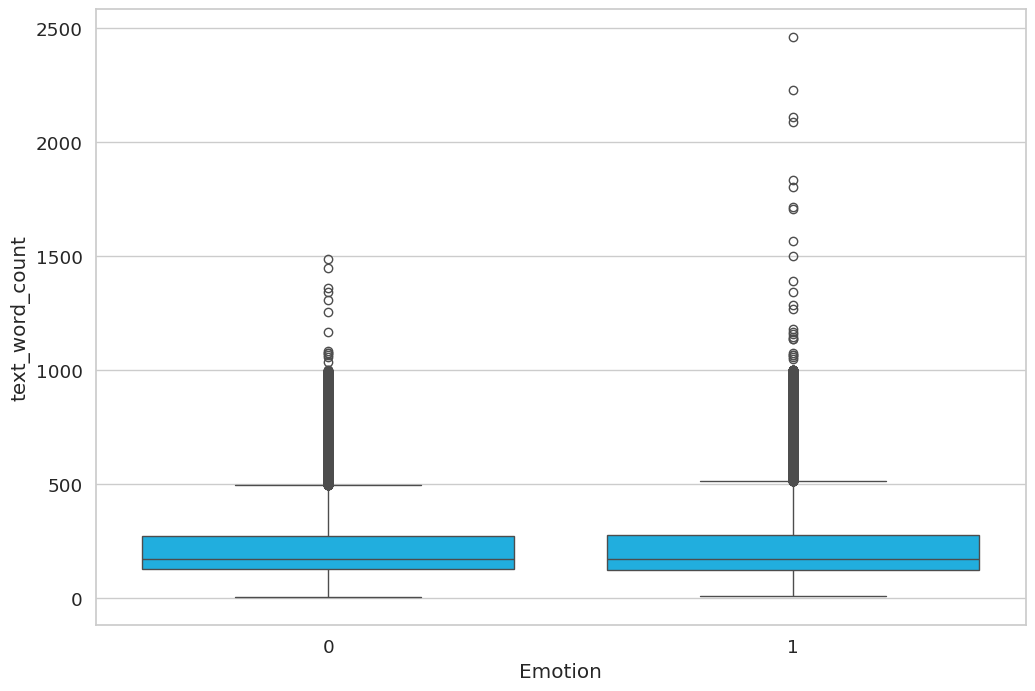

In [ ]:
sns.boxplot(x="Emotion", y="text_word_count", data=IMDB)

mean_word_count_by_label2 = filtered_IMDB.groupby('Emotion')['text_word_count'].mean()
print(mean_word_count_by_label2)

# Classic

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

def evaluate_model(df, dataset_name):
    X = df["Text"]
    y = df["Emotion"]

    # Encode labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.3, random_state=42
    )

    # Vectorization
    vectorizer = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 1),
        max_df=0.75,
        min_df=1,
        sublinear_tf=True
    )
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    # Compute centroids
    class_centroids = np.array([
        X_train_tfidf[y_train == label].mean(axis=0).A1
        for label in np.unique(y_train)
    ])

    # Rocchio classifier prediction
    def predict(X_tfidf):
        distances = euclidean_distances(X_tfidf, class_centroids)
        return np.argmin(distances, axis=1)

    y_pred = predict(X_test_tfidf)

    # Evaluation metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Return key metrics + confusion matrix
    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision (Negative)": report["0"]["precision"],
        "Recall (Negative)": report["0"]["recall"],
        "F1-Score (Negative)": report["0"]["f1-score"],
        "Precision (Positive)": report["1"]["precision"],
        "Recall (Positive)": report["1"]["recall"],
        "F1-Score (Positive)": report["1"]["f1-score"],
        "confusion_matrix": cm  # <- Added this so we can plot it later
    }

# Evaluate each dataset and combined dataset
results = []
results.append(evaluate_model(Gutenberg_Train, "Gutenberg"))
results.append(evaluate_model(IMDB, "IMDB"))
results.append(evaluate_model(data, "Combined"))

# Convert to DataFrame for easy visualization
df_results = pd.DataFrame(results)

# Print the main metrics table
print(df_results)

     Dataset  Accuracy  Precision (Negative)  Recall (Negative)  \
0  Gutenberg  0.630137              0.612245           0.789474   
1       IMDB  0.826800              0.856783           0.779787   
2   Combined  0.824720              0.857289           0.779002   

   F1-Score (Negative)  Precision (Positive)  Recall (Positive)  \
0             0.689655              0.666667           0.457143   
1             0.816474              0.802302           0.872711   
2             0.816273              0.797618           0.870407   

   F1-Score (Positive)             confusion_matrix  
0             0.542373          [[30, 8], [19, 16]]  
1             0.836026  [[5779, 1632], [966, 6623]]  
2             0.832424  [[5869, 1665], [977, 6562]]  


Dataset: Gutenberg
Accuracy: 0.630


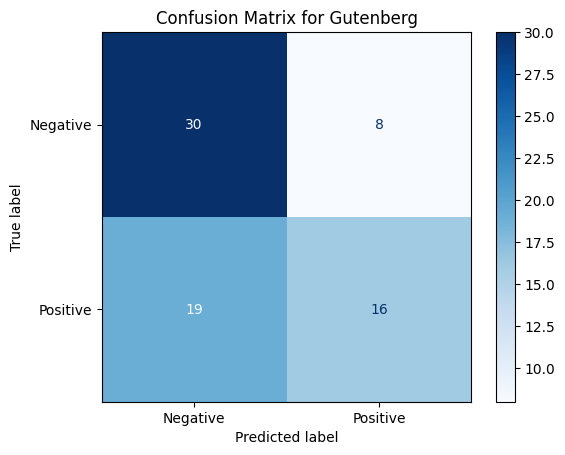

Dataset: IMDB
Accuracy: 0.827


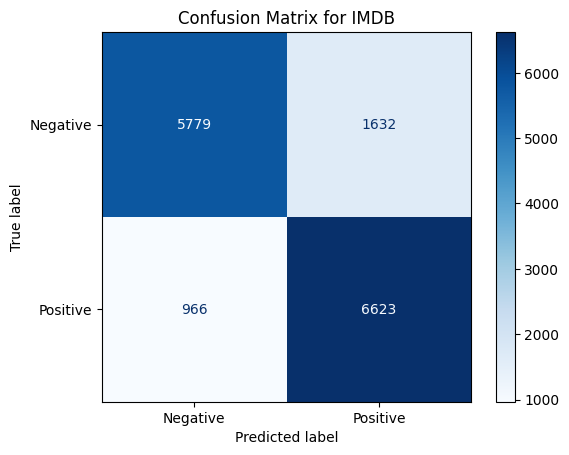

Dataset: Combined
Accuracy: 0.825


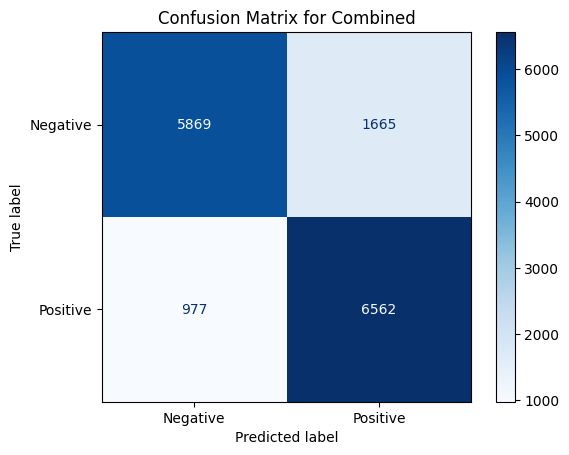

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# List of (DataFrame, Name) tuples for each dataset
datasets = [
    (Gutenberg_Train, "Gutenberg"),
    (IMDB, "IMDB"),
    (data, "Combined")
]

for df, dataset_name in datasets:
    # Run evaluation (this calls the updated evaluate_model)
    results = evaluate_model(df, dataset_name)

    # Print out accuracy
    print(f"Dataset: {dataset_name}")
    print(f"Accuracy: {results['Accuracy']:.3f}")

    # Retrieve the confusion matrix
    cm = results["confusion_matrix"]

    # Plot the confusion matrix with a blue colormap
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Negative", "Positive"]  # Adjust labels if needed
    )
    disp.plot(cmap='Blues')  # Use a blue colormap
    plt.title(f"Confusion Matrix for {dataset_name}")
    plt.show()


In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances

def train_rocchio_model(df):
    """
    Trains a Rocchio classifier on the entire dataset (df)
    and returns the vectorizer, label encoder, and class centroids.
    """
    # Separate features and labels
    X = df["Text"]
    y = df["Emotion"]

    # Encode labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    # Vectorize the entire dataset
    vectorizer = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 1),
        max_df=0.75,
        min_df=1,
        sublinear_tf=True
    )
    X_tfidf = vectorizer.fit_transform(X)

    # Compute class centroids in TF-IDF space
    class_centroids = np.array([
        X_tfidf[y_encoded == label].mean(axis=0).A1
        for label in np.unique(y_encoded)
    ])

    return vectorizer, label_encoder, class_centroids

In [ ]:
def predict_rocchio(new_texts, vectorizer, label_encoder, class_centroids):
    """
    Predict the emotion of new_texts using the Rocchio classifier.
    """
    # Transform the new texts into TF-IDF space
    X_new_tfidf = vectorizer.transform(new_texts)

    # Compute Euclidean distance to each class centroid
    distances = euclidean_distances(X_new_tfidf, class_centroids)

    # Predict the label whose centroid is closest
    predicted_label_indices = np.argmin(distances, axis=1)

    # Convert numeric labels back to original emotion labels
    predicted_emotions = label_encoder.inverse_transform(predicted_label_indices)
    return predicted_emotions

In [ ]:
# 3.1 Train on the combined dataset
vectorizer, label_encoder, class_centroids = train_rocchio_model(data)

In [ ]:
new_texts = [
    # Positive Single Words/Phrases
    "Great",
    "Amazing",
    "Well done",

    # Negative Single Words/Phrases
    "Terrible",
    "Pathetic",
    "Poorly done",

    # Enthusiastic/Positive Exclamations
    "Oooh, wow!",
    "That is terrific!",
    "That’s awesome!",

    # Negative/Critical Exclamations
    "This is terrible!",
    "Absolutely awful!",
    "This is so disappointing!",

    # Ironic Understatements
    "I wasn’t looking forward to it anyway",
    "Oh, this is just what I needed right now",


    # Rhetorical Questions
    "Really?",
    "Is that your best attempt?",
    "How could this possibly get any worse?",

   # Larger Positive, Negative, and Ambiguous Sentences (with simpler, poetic/landscape elements)
    "How sweet the moonlight sleeps upon this bank!",
    "Blow, winds, and crack your cheeks! rage! blow! ",
    "Fair is foul, and foul is fair: Hover through the fog and filthy air."
]

In [ ]:



# Use the Rocchio model to get predictions
predictions = predict_rocchio(new_texts, vectorizer, label_encoder, class_centroids)

for text, pred in zip(new_texts, predictions):
    print(f"Text: '{text}' --> Predicted Emotion: {pred}")

Text: 'Great' --> Predicted Emotion: 1
Text: 'Amazing' --> Predicted Emotion: 1
Text: 'Well done' --> Predicted Emotion: 1
Text: 'Terrible' --> Predicted Emotion: 0
Text: 'Pathetic' --> Predicted Emotion: 0
Text: 'Poorly done' --> Predicted Emotion: 0
Text: 'Oooh, wow!' --> Predicted Emotion: 1
Text: 'That is terrific!' --> Predicted Emotion: 1
Text: 'That’s awesome!' --> Predicted Emotion: 1
Text: 'This is terrible!' --> Predicted Emotion: 0
Text: 'Absolutely awful!' --> Predicted Emotion: 0
Text: 'This is so disappointing!' --> Predicted Emotion: 0
Text: 'I wasn’t looking forward to it anyway' --> Predicted Emotion: 1
Text: 'Oh, this is just what I needed right now' --> Predicted Emotion: 0
Text: 'Really?' --> Predicted Emotion: 0
Text: 'Is that your best attempt?' --> Predicted Emotion: 1
Text: 'How could this possibly get any worse?' --> Predicted Emotion: 0
Text: 'How sweet the moonlight sleeps upon this bank!' --> Predicted Emotion: 1
Text: 'Blow, winds, and crack your cheeks! ra

## With Lemma

In [ ]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

def evaluate_model(df, dataset_name):
    X = df["Text"]
    y = df["Emotion"]

    # Encode labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.3, random_state=42
    )

    # Vectorization
    vectorizer = TfidfVectorizer(
        stop_words='english',
        ngram_range=(1, 1),
        max_df=0.75,
        min_df=1,
        sublinear_tf=True
    )
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    # Compute centroids
    class_centroids = np.array([
        X_train_tfidf[y_train == label].mean(axis=0).A1
        for label in np.unique(y_train)
    ])

    # Rocchio classifier prediction
    def predict(X_tfidf):
        distances = euclidean_distances(X_tfidf, class_centroids)
        return np.argmin(distances, axis=1)

    y_pred = predict(X_test_tfidf)

    # Evaluation metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Return key metrics + confusion matrix
    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision (Negative)": report["0"]["precision"],
        "Recall (Negative)": report["0"]["recall"],
        "F1-Score (Negative)": report["0"]["f1-score"],
        "Precision (Positive)": report["1"]["precision"],
        "Recall (Positive)": report["1"]["recall"],
        "F1-Score (Positive)": report["1"]["f1-score"],
        "confusion_matrix": cm  # <- Added this so we can plot it later
    }

# Evaluate each dataset and combined dataset
results = []
results.append(evaluate_model(Gutenberg_Train2, "Gutenberg"))
results.append(evaluate_model(IMDB2, "IMDB"))
results.append(evaluate_model(data2, "Combined"))

# Convert to DataFrame for easy visualization
df_results = pd.DataFrame(results)

# Print the main metrics table
print(df_results)

     Dataset  Accuracy  Precision (Negative)  Recall (Negative)  \
0  Gutenberg  0.698630              0.673913           0.815789   
1       IMDB  0.830400              0.868099           0.774389   
2   Combined  0.829165              0.866086           0.778604   

   F1-Score (Negative)  Precision (Positive)  Recall (Positive)  \
0             0.738095              0.740741           0.571429   
1             0.818571              0.800691           0.885097   
2             0.820018              0.799036           0.879692   

   F1-Score (Positive)             confusion_matrix  
0             0.645161          [[31, 7], [15, 20]]  
1             0.840781  [[5739, 1672], [872, 6717]]  
2             0.837427  [[5866, 1668], [907, 6632]]  


## GLOVE

In [ ]:
# Download the zip file (2+ GB) from Hugging Face
!wget https://huggingface.co/stanfordnlp/glove/resolve/main/glove.840B.300d.zip -O glove.840B.300d.zip

# Unzip the file (will expand to ~5.5 GB)
!unzip glove.840B.300d.zip

--2025-03-26 16:40:48--  https://huggingface.co/stanfordnlp/glove/resolve/main/glove.840B.300d.zip
Resolving huggingface.co (huggingface.co)... 18.164.174.55, 18.164.174.17, 18.164.174.118, ...
Connecting to huggingface.co (huggingface.co)|18.164.174.55|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://cdn-lfs.hf.co/stanfordnlp/glove/f47355dd5b267bd10f08671e513790690233c76a9ffd73aa915d78f894a8912e?response-content-disposition=inline%3B+filename*%3DUTF-8%27%27glove.840B.300d.zip%3B+filename%3D%22glove.840B.300d.zip%22%3B&response-content-type=application%2Fzip&Expires=1743010848&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTc0MzAxMDg0OH19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9zdGFuZm9yZG5scC9nbG92ZS9mNDczNTVkZDViMjY3YmQxMGYwODY3MWU1MTM3OTA2OTAyMzNjNzZhOWZmZDczYWE5MTVkNzhmODk0YTg5MTJlP3Jlc3BvbnNlLWNvbnRlbnQtZGlzcG9zaXRpb249KiZyZXNwb25zZS1jb250ZW50LXR5cGU9KiJ9XX0_&Signature=v%7ELckNlZPUgHWtjA83D6mqFZWN

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Load GloVe embeddings
def load_glove_embeddings(filepath):
    embeddings = {}
    with open(filepath, encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split()
            word = parts[0]
            try:
                vector = np.array(parts[1:], dtype=np.float32)
                if vector.shape[0] == 300:  # Ensure correct embedding dimension
                    embeddings[word] = vector
            except ValueError:
                # Skip problematic lines
                continue
    return embeddings

# Document embedding as average of word embeddings
def document_embedding(text, embeddings, dim=300):
    words = text.split()
    vectors = [embeddings[word] for word in words if word in embeddings]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

# Main evaluation function using GloVe
def evaluate_model_glove(df, dataset_name, glove_embeddings, dim=300):
    X = df["Text"]
    y = df["Emotion"]

    # Encode labels
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.3, random_state=42
    )

    # Compute embeddings for documents
    X_train_emb = np.array([document_embedding(text, glove_embeddings, dim) for text in X_train])
    X_test_emb = np.array([document_embedding(text, glove_embeddings, dim) for text in X_test])

    # Compute centroids
    class_centroids = np.array([
        X_train_emb[y_train == label].mean(axis=0)
        for label in np.unique(y_train)
    ])

    # Rocchio classifier prediction
    def predict(X_emb):
        distances = euclidean_distances(X_emb, class_centroids)
        return np.argmin(distances, axis=1)

    y_pred = predict(X_test_emb)

    # Evaluation metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    accuracy = accuracy_score(y_test, y_pred)

    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Return key metrics + confusion matrix
    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Precision (Negative)": report["0"]["precision"],
        "Recall (Negative)": report["0"]["recall"],
        "F1-Score (Negative)": report["0"]["f1-score"],
        "Precision (Positive)": report["1"]["precision"],
        "Recall (Positive)": report["1"]["recall"],
        "F1-Score (Positive)": report["1"]["f1-score"],
        "confusion_matrix": cm
    }

# Load GloVe embeddings (change the path accordingly)
glove_filepath = "glove.840B.300d.txt"
glove_embeddings = load_glove_embeddings(glove_filepath)



In [ ]:
# Evaluate datasets
datasets = [
    (Gutenberg_Train, "Gutenberg"),
    (IMDB, "IMDB"),
    (data, "Combined")
]

results_glove = [evaluate_model_glove(df, name, glove_embeddings) for df, name in datasets]

# Convert to DataFrame and visualize
df_results_glove = pd.DataFrame(results_glove)

# Display results
print(df_results_glove)

     Dataset  Accuracy  Precision (Negative)  Recall (Negative)  \
0  Gutenberg  0.863014              0.818182           0.947368   
1       IMDB  0.690333              0.681782           0.699906   
2   Combined  0.694553              0.689914           0.706398   

   F1-Score (Negative)  Precision (Positive)  Recall (Positive)  \
0             0.878049              0.931034           0.771429   
1             0.690725              0.699134           0.680986   
2             0.698059              0.699416           0.682717   

   F1-Score (Positive)              confusion_matrix  
0             0.843750            [[36, 2], [8, 27]]  
1             0.689941  [[5187, 2224], [2421, 5168]]  
2             0.690965  [[5322, 2212], [2392, 5147]]  


# LSTM

LSTM

(https://www.kaggle.com/code/ngyptr/lstm-sentiment-analysis-keras)



## LSTM Gutenberg

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Define parameters
max_features = 2000  # Maximum number of words to consider
embed_dim = 128
lstm_out = 196
batch_size = 4

# Ensure proper tokenizer initialization
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(Gutenberg_Train['Text'].values)
X = tokenizer.texts_to_sequences(Gutenberg_Train['Text'].values)
X = pad_sequences(X)

# Ensure X is properly shaped
if len(X.shape) == 1:  # If X is a 1D array, reshape it
    X = pad_sequences(X)

# Define the model
model = Sequential([
    Embedding(max_features, embed_dim),
    SpatialDropout1D(0.4),
    LSTM(lstm_out, dropout=0.2, recurrent_dropout=0.2),
    Dense(2, activation='softmax')  # Adjust output size for categorical classification
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',  # Categorical crossentropy loss function for multi-class classification
    optimizer='adam',
    metrics=['accuracy']
)

# Build the model by calling it with an input shape
model.build(input_shape=(None, X.shape[1]))  # Explicitly build the model

print(model.summary())

# Prepare labels (ensure they're one-hot encoded)
Y = pd.get_dummies(Gutenberg_Train['Emotion']).values

# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

# Print shapes of data splits
print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

# Set up early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       # Metric to monitor
    patience=2,               # Number of epochs to wait for improvement
    verbose=1,                # Print messages when stopping
    restore_best_weights=True # Restore weights from the best epoch
)

# Train the model with early stopping
model.fit(
    X_train, Y_train,
    epochs=6,
    batch_size=batch_size,
    verbose=1,
    validation_data=(X_test, Y_test),  # Validate on test data during training
    callbacks=[early_stopping]          # Include early stopping callback
)

# Function to evaluate the model
def evaluate_model(model, X_test, Y_test):
    # Get model predictions
    Y_validate = model.predict(X_test)  # Predicted probabilities
    Y_validate_classes = np.argmax(Y_validate, axis=1)  # Convert to class labels

    # Convert Y_test to a single label if it is one-hot encoded
    if Y_test.ndim > 1:  # Checking if Y_test is one-hot encoded
        Y_test = np.argmax(Y_test, axis=1)  # Convert to single labels

    # Compute classification report
    report = classification_report(Y_test, Y_validate_classes, output_dict=True)

    # Compute accuracy
    accuracy = accuracy_score(Y_test, Y_validate_classes)

    # Format results
    return {
        "Accuracy": accuracy,
        "Precision (Negative)": report["0"]["precision"],
        "Recall (Negative)": report["0"]["recall"],
        "F1-Score (Negative)": report["0"]["f1-score"],
        "Precision (Positive)": report["1"]["precision"],
        "Recall (Positive)": report["1"]["recall"],
        "F1-Score (Positive)": report["1"]["f1-score"]
    }

# Example Usage:
results = evaluate_model(model, X_test, Y_test)
print(results)



Model: "sequential_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_38 (Embedding)             │ (None, 17, 128)             │         256,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_36                 │ (None, 17, 128)             │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_40 (LSTM)                       │ (None, 196)                 │         254,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_38 (Dense)                     │ (None, 2)                   │             394 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 511,194 (1.95 MB)

 Trainable params: 511,194 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

None
(182, 17) (182, 2)
(61, 17) (61, 2)
Epoch 1/6
46/46 ━━━━━━━━━━━━━━━━━━━━ 10s 95ms/step - accuracy: 0.4494 - loss: 0.6986 - val_accuracy: 0.5246 - val_loss: 0.6897
Epoch 2/6
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.6347 - loss: 0.6635 - val_accuracy: 0.6393 - val_loss: 0.6790
Epoch 3/6
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7966 - loss: 0.5544 - val_accuracy: 0.6066 - val_loss: 0.6906
Epoch 4/6
46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.9312 - loss: 0.2280 - val_accuracy: 0.4918 - val_loss: 0.8628
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step
{'Accuracy': 0.639344262295082, 'Precision (Negative)': 0.7272727272727273, 'Recall (Negative)': 0.5, 'F1-Score (Negative)': 0.5925925925925926, 'Precision (Positive)': 0.5897435897435898, 'Recall (Positive)': 0.7931034482758621, 'F1-Score (Positive)': 0.6764705882352942}


In [ ]:
results

{'Accuracy': 0.639344262295082,
 'Precision (Negative)': 0.7272727272727273,
 'Recall (Negative)': 0.5,
 'F1-Score (Negative)': 0.5925925925925926,
 'Precision (Positive)': 0.5897435897435898,
 'Recall (Positive)': 0.7931034482758621,
 'F1-Score (Positive)': 0.6764705882352942}

## LSTM IMDB

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Define parameters
max_features = 2000  # Maximum number of words to consider
embed_dim = 128
lstm_out = 196
batch_size = 512

# Ensure proper tokenizer initialization
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(IMDB['Text'].values)
X = tokenizer.texts_to_sequences(IMDB['Text'].values)
X = pad_sequences(X)

# Ensure X is properly shaped
if len(X.shape) == 1:  # If X is a 1D array, reshape it
    X = pad_sequences(X)

# Define the model
model = Sequential([
    Embedding(max_features, embed_dim),
    SpatialDropout1D(0.4),
    LSTM(lstm_out, dropout=0.2, recurrent_dropout=0.2),
    Dense(2, activation='softmax')  # Adjust output size for categorical classification
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',  # Categorical crossentropy loss function for multi-class classification
    optimizer='adam',
    metrics=['accuracy']
)

# Build the model by calling it with an input shape
model.build(input_shape=(None, X.shape[1]))  # Explicitly build the model

print(model.summary())

# Prepare labels (ensure they're one-hot encoded)
Y = pd.get_dummies(IMDB['Emotion']).values

# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

# Print shapes of data splits
print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

# Set up early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       # Metric to monitor
    patience=2,               # Number of epochs to wait for improvement
    verbose=1,                # Print messages when stopping
    restore_best_weights=True # Restore weights from the best epoch
)

# Train the model with early stopping
model.fit(
    X_train, Y_train,
    epochs=2,
    batch_size=batch_size,
    verbose=1,
    validation_data=(X_test, Y_test),  # Validate on test data during training
    callbacks=[early_stopping]          # Include early stopping callback
)

# Function to evaluate the model
def evaluate_model(model, X_test, Y_test):
    # Get model predictions
    Y_validate = model.predict(X_test)  # Predicted probabilities
    Y_validate_classes = np.argmax(Y_validate, axis=1)  # Convert to class labels

    # Convert Y_test to a single label if it is one-hot encoded
    if Y_test.ndim > 1:  # Checking if Y_test is one-hot encoded
        Y_test = np.argmax(Y_test, axis=1)  # Convert to single labels

    # Compute classification report
    report = classification_report(Y_test, Y_validate_classes, output_dict=True)

    # Compute accuracy
    accuracy = accuracy_score(Y_test, Y_validate_classes)

    # Format results
    return {
        "Accuracy": accuracy,
        "Precision (Negative)": report["0"]["precision"],
        "Recall (Negative)": report["0"]["recall"],
        "F1-Score (Negative)": report["0"]["f1-score"],
        "Precision (Positive)": report["1"]["precision"],
        "Recall (Positive)": report["1"]["recall"],
        "F1-Score (Positive)": report["1"]["f1-score"]
    }

# Example Usage:
results = evaluate_model(model, X_test, Y_test)
print(results)



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 1844, 128)           │         256,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_1                  │ (None, 1844, 128)           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 196)                 │         254,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             394 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 511,194 (1.95 MB)

 Trainable params: 511,194 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

None
(37500, 1844) (37500, 2)
(12500, 1844) (12500, 2)
Epoch 1/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 496s 7s/step - accuracy: 0.6453 - loss: 0.6286 - val_accuracy: 0.8311 - val_loss: 0.3938
Epoch 2/2
74/74 ━━━━━━━━━━━━━━━━━━━━ 517s 7s/step - accuracy: 0.8339 - loss: 0.3836 - val_accuracy: 0.8439 - val_loss: 0.3619
Restoring model weights from the end of the best epoch: 2.
391/391 ━━━━━━━━━━━━━━━━━━━━ 397s 1s/step
{'Accuracy': 0.84392, 'Precision (Negative)': 0.8781014023732471, 'Recall (Negative)': 0.7932434627253533, 'F1-Score (Negative)': 0.8335182182780101, 'Precision (Positive)': 0.8165177284520034, 'Recall (Positive)': 0.8931105155289295, 'F1-Score (Positive)': 0.853098411264212}


In [ ]:
results

{'Accuracy': 0.84392,
 'Precision (Negative)': 0.8781014023732471,
 'Recall (Negative)': 0.7932434627253533,
 'F1-Score (Negative)': 0.8335182182780101,
 'Precision (Positive)': 0.8165177284520034,
 'Recall (Positive)': 0.8931105155289295,
 'F1-Score (Positive)': 0.853098411264212}

## LSTM Combined

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, SpatialDropout1D
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Define parameters
max_features = 2000  # Maximum number of words to consider
embed_dim = 128
lstm_out = 196
batch_size = 512

# Ensure proper tokenizer initialization
tokenizer = Tokenizer(num_words=max_features, split=' ')
tokenizer.fit_on_texts(data['Text'].values)
X = tokenizer.texts_to_sequences(data['Text'].values)
X = pad_sequences(X)

# Ensure X is properly shaped
if len(X.shape) == 1:  # If X is a 1D array, reshape it
    X = pad_sequences(X)

# Define the model
model = Sequential([
    Embedding(max_features, embed_dim),
    SpatialDropout1D(0.4),
    LSTM(lstm_out, dropout=0.2, recurrent_dropout=0.2),
    Dense(2, activation='softmax')  # Adjust output size for categorical classification
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',  # Categorical crossentropy loss function for multi-class classification
    optimizer='adam',
    metrics=['accuracy']
)

# Build the model by calling it with an input shape
model.build(input_shape=(None, X.shape[1]))  # Explicitly build the model

print(model.summary())

# Prepare labels (ensure they're one-hot encoded)
Y = pd.get_dummies(data['Emotion']).values

# Split data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state=42)

# Print shapes of data splits
print(X_train.shape, Y_train.shape)
print(X_test.shape, Y_test.shape)

# Set up early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',       # Metric to monitor
    patience=2,               # Number of epochs to wait for improvement
    verbose=1,                # Print messages when stopping
    restore_best_weights=True # Restore weights from the best epoch
)

# Train the model with early stopping
model.fit(
    X_train, Y_train,
    epochs=6,
    batch_size=batch_size,
    verbose=1,
    validation_data=(X_test, Y_test),  # Validate on test data during training
    callbacks=[early_stopping]          # Include early stopping callback
)

# Function to evaluate the model
def evaluate_model(model, X_test, Y_test):
    # Get model predictions
    Y_validate = model.predict(X_test)  # Predicted probabilities
    Y_validate_classes = np.argmax(Y_validate, axis=1)  # Convert to class labels

    # Convert Y_test to a single label if it is one-hot encoded
    if Y_test.ndim > 1:  # Checking if Y_test is one-hot encoded
        Y_test = np.argmax(Y_test, axis=1)  # Convert to single labels

    # Compute classification report
    report = classification_report(Y_test, Y_validate_classes, output_dict=True)

    # Compute accuracy
    accuracy = accuracy_score(Y_test, Y_validate_classes)

    # Format results
    return {
        "Accuracy": accuracy,
        "Precision (Negative)": report["0"]["precision"],
        "Recall (Negative)": report["0"]["recall"],
        "F1-Score (Negative)": report["0"]["f1-score"],
        "Precision (Positive)": report["1"]["precision"],
        "Recall (Positive)": report["1"]["recall"],
        "F1-Score (Positive)": report["1"]["f1-score"]
    }

# Example Usage:
results = evaluate_model(model, X_test, Y_test)
print(results)



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 1844, 128)           │         256,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ spatial_dropout1d_2                  │ (None, 1844, 128)           │               0 │
│ (SpatialDropout1D)                   │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 196)                 │         254,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             394 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 511,194 (1.95 MB)

 Trainable params: 511,194 (1.95 MB)

 Non-trainable params: 0 (0.00 B)

None
(37682, 1844) (37682, 2)
(12561, 1844) (12561, 2)
Epoch 1/6
74/74 ━━━━━━━━━━━━━━━━━━━━ 531s 7s/step - accuracy: 0.6561 - loss: 0.6151 - val_accuracy: 0.8533 - val_loss: 0.3449
Epoch 2/6
74/74 ━━━━━━━━━━━━━━━━━━━━ 543s 7s/step - accuracy: 0.8360 - loss: 0.3831 - val_accuracy: 0.8588 - val_loss: 0.3425
Epoch 3/6
74/74 ━━━━━━━━━━━━━━━━━━━━ 562s 7s/step - accuracy: 0.8543 - loss: 0.3511 - val_accuracy: 0.8188 - val_loss: 0.4113
Epoch 4/6
74/74 ━━━━━━━━━━━━━━━━━━━━ 566s 7s/step - accuracy: 0.8469 - loss: 0.3650 - val_accuracy: 0.8551 - val_loss: 0.3421
Epoch 5/6
74/74 ━━━━━━━━━━━━━━━━━━━━ 562s 7s/step - accuracy: 0.8602 - loss: 0.3386 - val_accuracy: 0.8731 - val_loss: 0.3152
Epoch 6/6
74/74 ━━━━━━━━━━━━━━━━━━━━ 562s 7s/step - accuracy: 0.8698 - loss: 0.3156 - val_accuracy: 0.8721 - val_loss: 0.3073
Restoring model weights from the end of the best epoch: 6.
393/393 ━━━━━━━━━━━━━━━━━━━━ 395s 1s/step
{'Accuracy': 0.8721439375845872, 'Precision (Negative)': 0.9057157658435503, 'Recall (Ne

# BERT Fine Tuning

In [ ]:
# Install the required package
!pip install bert-for-tf2

In [ ]:
data

,Text,Emotion
0,with pale blue berries in these peaceful shades,1
2,and that is why the lonesome day,0
8,and so on then a worthless gaud or two,0
16,that has a charmingly bourbon air,1
17,sounded oer earth and sea its blast of war,0
...,...,...
883,by deaths frequented ways,0
885,rejection of his humanness,0
888,the one good man in the world who knows me,1
889,faint voices lifted shrill with pain,0


In [ ]:
Gutenberg_Train = preprocess(Gutenberg_Train)
IMDB = preprocess(IMDB)

# Standardize labels to 0 (Negative) and 1 (Positive)
Gutenberg_Train["Emotion"] = Gutenberg_Train["Emotion"].replace({-1: 0, 1: 1})

data = pd.concat([Gutenberg_Train, IMDB], ignore_index=True)

## BERT Gutenberg

In [ ]:
data = Gutenberg_Train
data

,Text,Emotion
0,with pale blue berries in these peaceful shades,1
2,and that is why the lonesome day,0
8,and so on then a worthless gaud or two,0
16,that has a charmingly bourbon air,1
17,sounded oer earth and sea its blast of war,0
...,...,...
883,by deaths frequented ways,0
885,rejection of his humanness,0
888,the one good man in the world who knows me,1
889,faint voices lifted shrill with pain,0


In [ ]:
import tensorflow as tf
from transformers import TFBertForSequenceClassification, BertTokenizer, AdamWeightDecay
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Hyperparameters
BATCH_SIZE = 16
EPOCHS = 6
MAX_SEQ_LEN = 128

# Load BERT model and tokenizer
model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Function to tokenize and convert sentences to features
def convert_sentences_to_features(sentences, tokenizer, max_length):
    input_ids, attention_masks = [], []

    for sentence in sentences:
        encoding = tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            return_attention_mask=True,
            truncation=True
        )
        input_ids.append(encoding['input_ids'])
        attention_masks.append(encoding['attention_mask'])

    return tf.constant(input_ids), tf.constant(attention_masks)

# Sample and split the data
# Replace `data` with your actual DataFrame
sampled_df = data.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    sampled_df,
    test_size=0.3,
    stratify=sampled_df['Emotion'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['Emotion'],
    random_state=42
)

# Prepare labels
y_train = np.array(train_df['Emotion'].values).astype(np.int32)
y_val = np.array(val_df['Emotion'].values).astype(np.int32)
y_test = np.array(test_df['Emotion'].values).astype(np.int32)

# Tokenize the text data
x_train_ids, x_train_masks = convert_sentences_to_features(train_df['Text'], tokenizer, MAX_SEQ_LEN)
x_val_ids, x_val_masks = convert_sentences_to_features(val_df['Text'], tokenizer, MAX_SEQ_LEN)
x_test_ids, x_test_masks = convert_sentences_to_features(test_df['Text'], tokenizer, MAX_SEQ_LEN)

# Create TensorFlow datasets
train_data = tf.data.Dataset.from_tensor_slices(((x_train_ids, x_train_masks), y_train)).batch(BATCH_SIZE)
val_data = tf.data.Dataset.from_tensor_slices(((x_val_ids, x_val_masks), y_val)).batch(BATCH_SIZE)
test_data = tf.data.Dataset.from_tensor_slices(((x_test_ids, x_test_masks), y_test)).batch(BATCH_SIZE)

# Optimizer
optimizer = AdamWeightDecay(learning_rate=2e-5)

# Compile the model
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# EarlyStopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # metric to monitor
    patience=2,             # stop after 2 epochs with no improvement
    restore_best_weights=True
)

# Train the model with early stopping
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/6
11/11 [==============================] - 25s 504ms/step - loss: 0.6942 - accuracy: 0.5471 - val_loss: 0.6859 - val_accuracy: 0.5556
Epoch 2/6
11/11 [==============================] - 1s 101ms/step - loss: 0.6223 - accuracy: 0.6824 - val_loss: 0.6204 - val_accuracy: 0.6944
Epoch 3/6
11/11 [==============================] - 1s 100ms/step - loss: 0.4558 - accuracy: 0.8529 - val_loss: 0.4586 - val_accuracy: 0.9167
Epoch 4/6
11/11 [==============================] - 1s 97ms/step - loss: 0.2629 - accuracy: 0.9412 - val_loss: 0.3979 - val_accuracy: 0.8611
Epoch 5/6
11/11 [==============================] - 1s 100ms/step - loss: 0.1500 - accuracy: 0.9588 - val_loss: 0.2260 - val_accuracy: 0.9167
Epoch 6/6
3/3 [==============================] - 0s 30ms/step - loss: 0.3093 - accuracy: 0.9189
Test Loss: 0.3093 | Test Accuracy: 0.9189


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# 1. Predict on the test dataset
y_pred_labels = []
y_true_labels = []

for (input_batch, label_batch) in test_data:
    logits = model(input_batch).logits
    batch_preds = tf.argmax(logits, axis=1)
    y_pred_labels.extend(batch_preds.numpy())
    y_true_labels.extend(label_batch.numpy())

# Convert to numpy arrays
y_true_labels = np.array(y_true_labels)
y_pred_labels = np.array(y_pred_labels)

# 2. Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
print("Confusion Matrix:")
print(cm)

# 3. Classification report (includes F1-scores for each class)
report = classification_report(y_true_labels, y_pred_labels, digits=4)
print("Classification Report:")
print(report)

# 4. Optionally, separate F1-scores (macro, micro, weighted)
f1_macro = f1_score(y_true_labels, y_pred_labels, average='macro')
f1_micro = f1_score(y_true_labels, y_pred_labels, average='micro')
f1_weighted = f1_score(y_true_labels, y_pred_labels, average='weighted')

print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")

Confusion Matrix:
[[19  1]
 [ 2 15]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9048    0.9500    0.9268        20
           1     0.9375    0.8824    0.9091        17

    accuracy                         0.9189        37
   macro avg     0.9211    0.9162    0.9180        37
weighted avg     0.9198    0.9189    0.9187        37

F1 Macro: 0.9180
F1 Micro: 0.9189
F1 Weighted: 0.9187


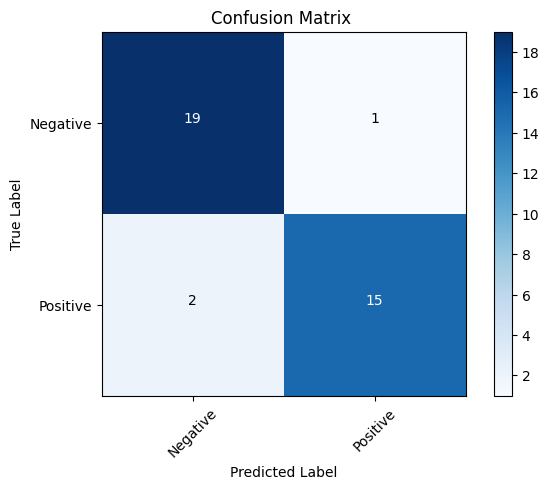

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Suppose you already have:
# y_true_labels = np.array([...])    # true labels
# y_pred_labels = np.array([...])    # predicted labels

# 1. Compute confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# If you have 3 classes, for instance:
class_names = ["Negative", "Positive"]

# 2. Plot confusion matrix
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix ")
plt.colorbar()

# Set up tick marks
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# 3. Label each cell with the numeric value
# We choose white vs. black text color for better visibility
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            format(cm[i, j], 'd'),   # integer format
            horizontalalignment='center',
            color='white' if cm[i, j] > thresh else 'black'
        )

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


## BERT IMDB

In [ ]:
data = IMDB
data

,Text,Emotion
1,one of the other reviewers has mentioned that ...,1
2,a wonderful little production the filming te...,1
3,i thought this was a wonderful way to spend ti...,1
4,basically theres a family where a little boy j...,0
5,petter matteis love in the time of money is a ...,1
...,...,...
49996,i thought this movie did a down right good job...,1
49997,bad plot bad dialogue bad acting idiotic direc...,0
49998,i am a catholic taught in parochial elementary...,0
49999,im going to have to disagree with the previous...,0


In [ ]:
import tensorflow as tf
from transformers import TFBertForSequenceClassification, BertTokenizer, AdamWeightDecay
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Hyperparameters
BATCH_SIZE = 16
EPOCHS = 4
MAX_SEQ_LEN = 128

# Load BERT model and tokenizer
model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Function to tokenize and convert sentences to features
def convert_sentences_to_features(sentences, tokenizer, max_length):
    input_ids, attention_masks = [], []

    for sentence in sentences:
        encoding = tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            return_attention_mask=True,
            truncation=True
        )
        input_ids.append(encoding['input_ids'])
        attention_masks.append(encoding['attention_mask'])

    return tf.constant(input_ids), tf.constant(attention_masks)

# Sample and split the data
# Replace `data` with your actual DataFrame
sampled_df = data.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    sampled_df,
    test_size=0.3,
    stratify=sampled_df['Emotion'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['Emotion'],
    random_state=42
)

# Prepare labels
y_train = np.array(train_df['Emotion'].values).astype(np.int32)
y_val = np.array(val_df['Emotion'].values).astype(np.int32)
y_test = np.array(test_df['Emotion'].values).astype(np.int32)

# Tokenize the text data
x_train_ids, x_train_masks = convert_sentences_to_features(train_df['Text'], tokenizer, MAX_SEQ_LEN)
x_val_ids, x_val_masks = convert_sentences_to_features(val_df['Text'], tokenizer, MAX_SEQ_LEN)
x_test_ids, x_test_masks = convert_sentences_to_features(test_df['Text'], tokenizer, MAX_SEQ_LEN)

# Create TensorFlow datasets
train_data = tf.data.Dataset.from_tensor_slices(((x_train_ids, x_train_masks), y_train)).batch(BATCH_SIZE)
val_data = tf.data.Dataset.from_tensor_slices(((x_val_ids, x_val_masks), y_val)).batch(BATCH_SIZE)
test_data = tf.data.Dataset.from_tensor_slices(((x_test_ids, x_test_masks), y_test)).batch(BATCH_SIZE)

# Optimizer
optimizer = AdamWeightDecay(learning_rate=2e-5)

# Compile the model
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# EarlyStopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # metric to monitor
    patience=2,             # stop after 2 epochs with no improvement
    restore_best_weights=True
)

# Train the model with early stopping
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/4
2188/2188 [==============================] - 173s 71ms/step - loss: 0.3121 - accuracy: 0.8633 - val_loss: 0.2584 - val_accuracy: 0.8909
Epoch 2/4
2188/2188 [==============================] - 151s 69ms/step - loss: 0.1714 - accuracy: 0.9351 - val_loss: 0.2978 - val_accuracy: 0.8868
Epoch 3/4
469/469 [==============================] - 13s 29ms/step - loss: 0.2467 - accuracy: 0.8968
Test Loss: 0.2467 | Test Accuracy: 0.8968


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# 1. Predict on the test dataset
y_pred_labels = []
y_true_labels = []

for (input_batch, label_batch) in test_data:
    logits = model(input_batch).logits
    batch_preds = tf.argmax(logits, axis=1)
    y_pred_labels.extend(batch_preds.numpy())
    y_true_labels.extend(label_batch.numpy())

# Convert to numpy arrays
y_true_labels = np.array(y_true_labels)
y_pred_labels = np.array(y_pred_labels)

# 2. Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
print("Confusion Matrix:")
print(cm)

# 3. Classification report (includes F1-scores for each class)
report = classification_report(y_true_labels, y_pred_labels, digits=4)
print("Classification Report:")
print(report)

# 4. Optionally, separate F1-scores (macro, micro, weighted)
f1_macro = f1_score(y_true_labels, y_pred_labels, average='macro')
f1_micro = f1_score(y_true_labels, y_pred_labels, average='micro')
f1_weighted = f1_score(y_true_labels, y_pred_labels, average='weighted')

print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")

Confusion Matrix:
[[3225  525]
 [ 248 3502]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9286    0.8600    0.8930      3750
           1     0.8696    0.9339    0.9006      3750

    accuracy                         0.8969      7500
   macro avg     0.8991    0.8969    0.8968      7500
weighted avg     0.8991    0.8969    0.8968      7500

F1 Macro: 0.8968
F1 Micro: 0.8969
F1 Weighted: 0.8968


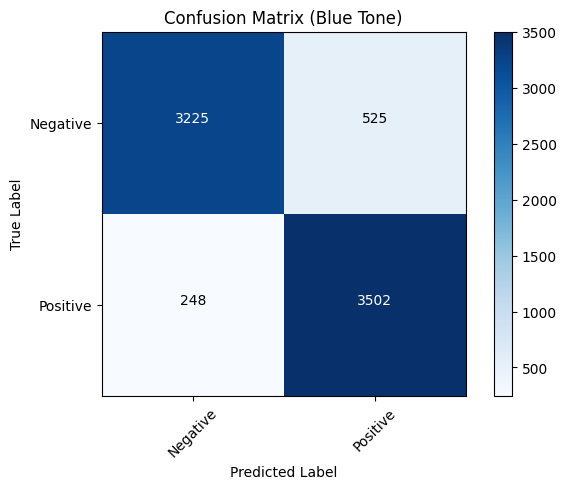

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Suppose you already have:
# y_true_labels = np.array([...])    # true labels
# y_pred_labels = np.array([...])    # predicted labels

# 1. Compute confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# If you have 3 classes, for instance:
class_names = ["Negative", "Positive"]

# 2. Plot confusion matrix
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Blue Tone)")
plt.colorbar()

# Set up tick marks
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# 3. Label each cell with the numeric value
# We choose white vs. black text color for better visibility
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            format(cm[i, j], 'd'),   # integer format
            horizontalalignment='center',
            color='white' if cm[i, j] > thresh else 'black'
        )

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## BERT Combined

In [ ]:
data = pd.concat([Gutenberg_Train, IMDB], ignore_index=True)
data

,Text,Emotion
0,with pale blue berries in these peaceful shades,1
1,and that is why the lonesome day,0
2,and so on then a worthless gaud or two,0
3,that has a charmingly bourbon air,1
4,sounded oer earth and sea its blast of war,0
...,...,...
50238,i thought this movie did a down right good job...,1
50239,bad plot bad dialogue bad acting idiotic direc...,0
50240,i am a catholic taught in parochial elementary...,0
50241,im going to have to disagree with the previous...,0


In [ ]:
import tensorflow as tf
from transformers import TFBertForSequenceClassification, BertTokenizer, AdamWeightDecay
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

# Hyperparameters
BATCH_SIZE = 16
EPOCHS = 4
MAX_SEQ_LEN = 128

# Load BERT model and tokenizer
model = TFBertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Function to tokenize and convert sentences to features
def convert_sentences_to_features(sentences, tokenizer, max_length):
    input_ids, attention_masks = [], []

    for sentence in sentences:
        encoding = tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            return_attention_mask=True,
            truncation=True
        )
        input_ids.append(encoding['input_ids'])
        attention_masks.append(encoding['attention_mask'])

    return tf.constant(input_ids), tf.constant(attention_masks)

# Sample and split the data
# Replace `data` with your actual DataFrame
sampled_df = data.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    sampled_df,
    test_size=0.3,
    stratify=sampled_df['Emotion'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['Emotion'],
    random_state=42
)

# Prepare labels
y_train = np.array(train_df['Emotion'].values).astype(np.int32)
y_val = np.array(val_df['Emotion'].values).astype(np.int32)
y_test = np.array(test_df['Emotion'].values).astype(np.int32)

# Tokenize the text data
x_train_ids, x_train_masks = convert_sentences_to_features(train_df['Text'], tokenizer, MAX_SEQ_LEN)
x_val_ids, x_val_masks = convert_sentences_to_features(val_df['Text'], tokenizer, MAX_SEQ_LEN)
x_test_ids, x_test_masks = convert_sentences_to_features(test_df['Text'], tokenizer, MAX_SEQ_LEN)

# Create TensorFlow datasets
train_data = tf.data.Dataset.from_tensor_slices(((x_train_ids, x_train_masks), y_train)).batch(BATCH_SIZE)
val_data = tf.data.Dataset.from_tensor_slices(((x_val_ids, x_val_masks), y_val)).batch(BATCH_SIZE)
test_data = tf.data.Dataset.from_tensor_slices(((x_test_ids, x_test_masks), y_test)).batch(BATCH_SIZE)

# Optimizer
optimizer = AdamWeightDecay(learning_rate=2e-5)

# Compile the model
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# EarlyStopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',     # metric to monitor
    patience=2,             # stop after 2 epochs with no improvement
    restore_best_weights=True
)

# Train the model with early stopping
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/4
2199/2199 [==============================] - 173s 71ms/step - loss: 0.3070 - accuracy: 0.8665 - val_loss: 0.2496 - val_accuracy: 0.8966
Epoch 2/4
2199/2199 [==============================] - 152s 69ms/step - loss: 0.1719 - accuracy: 0.9358 - val_loss: 0.2651 - val_accuracy: 0.9025
Epoch 3/4
472/472 [==============================] - 14s 29ms/step - loss: 0.2608 - accuracy: 0.8896
Test Loss: 0.2608 | Test Accuracy: 0.8896


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report, f1_score

# 1. Predict on the test dataset
y_pred_labels = []
y_true_labels = []

for (input_batch, label_batch) in test_data:
    logits = model(input_batch).logits
    batch_preds = tf.argmax(logits, axis=1)
    y_pred_labels.extend(batch_preds.numpy())
    y_true_labels.extend(label_batch.numpy())

# Convert to numpy arrays
y_true_labels = np.array(y_true_labels)
y_pred_labels = np.array(y_pred_labels)

# 2. Confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
print("Confusion Matrix:")
print(cm)

# 3. Classification report (includes F1-scores for each class)
report = classification_report(y_true_labels, y_pred_labels, digits=4)
print("Classification Report:")
print(report)

# 4. Optionally, separate F1-scores (macro, micro, weighted)
f1_macro = f1_score(y_true_labels, y_pred_labels, average='macro')
f1_micro = f1_score(y_true_labels, y_pred_labels, average='micro')
f1_weighted = f1_score(y_true_labels, y_pred_labels, average='weighted')

print(f"F1 Macro: {f1_macro:.4f}")
print(f"F1 Micro: {f1_micro:.4f}")
print(f"F1 Weighted: {f1_weighted:.4f}")

Confusion Matrix:
[[3443  327]
 [ 505 3262]]
Classification Report:
              precision    recall  f1-score   support

           0     0.8721    0.9133    0.8922      3770
           1     0.9089    0.8659    0.8869      3767

    accuracy                         0.8896      7537
   macro avg     0.8905    0.8896    0.8895      7537
weighted avg     0.8905    0.8896    0.8895      7537

F1 Macro: 0.8895
F1 Micro: 0.8896
F1 Weighted: 0.8895


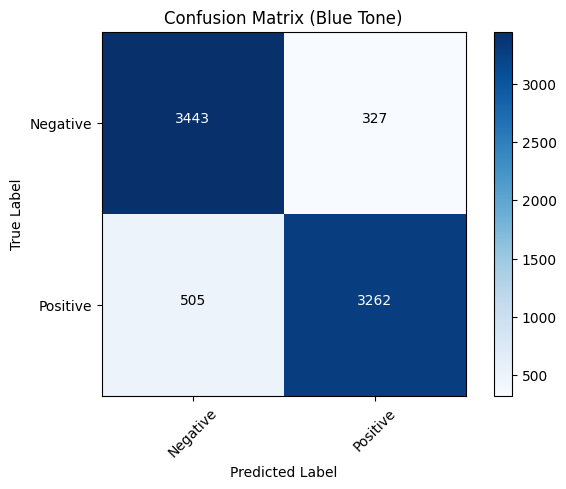

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Suppose you already have:
# y_true_labels = np.array([...])    # true labels
# y_pred_labels = np.array([...])    # predicted labels

# 1. Compute confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# If you have 3 classes, for instance:
class_names = ["Negative", "Positive"]

# 2. Plot confusion matrix
plt.figure()
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix (Blue Tone)")
plt.colorbar()

# Set up tick marks
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=45)
plt.yticks(tick_marks, class_names)

# 3. Label each cell with the numeric value
# We choose white vs. black text color for better visibility
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i,
            format(cm[i, j], 'd'),   # integer format
            horizontalalignment='center',
            color='white' if cm[i, j] > thresh else 'black'
        )

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# BERT Combined + EXTRA Layer

In [ ]:
data = pd.concat([Gutenberg_Train, IMDB], ignore_index=True)
data

,Text,Emotion
0,with pale blue berries in these peaceful shades,1
1,and that is why the lonesome day,0
2,and so on then a worthless gaud or two,0
3,that has a charmingly bourbon air,1
4,sounded oer earth and sea its blast of war,0
...,...,...
50238,i thought this movie did a down right good job...,1
50239,bad plot bad dialogue bad acting idiotic direc...,0
50240,i am a catholic taught in parochial elementary...,0
50241,im going to have to disagree with the previous...,0


In [ ]:
import tensorflow as tf
from transformers import TFBertForSequenceClassification, BertTokenizer, AdamWeightDecay
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

class TFBertWithExtraLayer(tf.keras.Model):
    """
    Wraps TFBertForSequenceClassification and adds
    an extra Dense + Dropout layer (or more if needed).
    """
    def __init__(self, base_model_name="bert-base-uncased", num_labels=2, dropout_rate=0.15, hidden_dim=768):
        super().__init__()
        # 1) Base classification model
        self.bert_sc = TFBertForSequenceClassification.from_pretrained(
            base_model_name,
            num_labels=num_labels
        )
        # 2) Extra hidden + dropout + final classification layer
        self.hidden = tf.keras.layers.Dense(hidden_dim, activation='relu')
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
        self.classifier = tf.keras.layers.Dense(num_labels)
        # ^ no activation => logits; we'll use from_logits=True

    def call(self, inputs, training=False):
        # Pass inputs through TFBertForSequenceClassification
        outputs = self.bert_sc(inputs, training=training)
        # 'outputs.logits' has shape (batch_size, num_labels)
        logits = outputs.logits

        # Our extra hidden + dropout + final layer
        x = self.hidden(logits)
        x = self.dropout(x, training=training)
        final_logits = self.classifier(x)
        return final_logits

In [ ]:
# Hyperparameters
BATCH_SIZE = 8
EPOCHS = 4
MAX_SEQ_LEN = 512

# Instantiate the custom model
model = TFBertWithExtraLayer(
    base_model_name="bert-base-uncased",
    num_labels=2,
    dropout_rate=0.15,   # Adjust if needed
    hidden_dim=768       # Adjust if needed
)

# Load the same tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Function to tokenize and convert sentences to features
def convert_sentences_to_features(sentences, tokenizer, max_length):
    input_ids, attention_masks = [], []

    for sentence in sentences:
        encoding = tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            return_attention_mask=True,
            truncation=True
        )
        input_ids.append(encoding['input_ids'])
        attention_masks.append(encoding['attention_mask'])

    return tf.constant(input_ids), tf.constant(attention_masks)

# -------------------------------------------------------------------------
# EXAMPLE DATA PREPARATION - Replace `data` with your actual DataFrame
# -------------------------------------------------------------------------
sampled_df = data.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    sampled_df,
    test_size=0.3,
    stratify=sampled_df['Emotion'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['Emotion'],
    random_state=42
)

# Prepare labels
y_train = np.array(train_df['Emotion'].values).astype(np.int32)
y_val   = np.array(val_df['Emotion'].values).astype(np.int32)
y_test  = np.array(test_df['Emotion'].values).astype(np.int32)

# Tokenize the text data
x_train_ids, x_train_masks = convert_sentences_to_features(train_df['Text'], tokenizer, MAX_SEQ_LEN)
x_val_ids, x_val_masks     = convert_sentences_to_features(val_df['Text'], tokenizer, MAX_SEQ_LEN)
x_test_ids, x_test_masks   = convert_sentences_to_features(test_df['Text'], tokenizer, MAX_SEQ_LEN)

# Create TensorFlow Datasets
train_data = tf.data.Dataset.from_tensor_slices((
    {"input_ids": x_train_ids, "attention_mask": x_train_masks},  # Keys must match TFBert input
    y_train
)).batch(BATCH_SIZE)

val_data = tf.data.Dataset.from_tensor_slices((
    {"input_ids": x_val_ids, "attention_mask": x_val_masks},
    y_val
)).batch(BATCH_SIZE)

test_data = tf.data.Dataset.from_tensor_slices((
    {"input_ids": x_test_ids, "attention_mask": x_test_masks},
    y_test
)).batch(BATCH_SIZE)

# -------------------------------------------------------------------------
# MODEL COMPILATION / TRAINING
# -------------------------------------------------------------------------
optimizer = AdamWeightDecay(learning_rate=3e-5)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# EarlyStopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")



All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/4
4397/4397 [==============================] - 601s 133ms/step - loss: 0.2487 - accuracy: 0.9016 - val_loss: 0.2238 - val_accuracy: 0.9033
Epoch 2/4
4397/4397 [==============================] - 582s 132ms/step - loss: 0.1272 - accuracy: 0.9545 - val_loss: 0.2125 - val_accuracy: 0.9199
Epoch 3/4
4397/4397 [==============================] - 581s 132ms/step - loss: 0.0768 - accuracy: 0.9746 - val_loss: 0.2784 - val_accuracy: 0.9258
Epoch 4/4
943/943 [==============================] - 46s 49ms/step - loss: 0.2120 - accuracy: 0.9302
Test Loss: 0.2120 | Test Accuracy: 0.9302


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix

# Predict on the test dataset
test_predictions = model.predict(test_data)

# test_predictions is a ModelOutput object with a "logits" attribute
# if you’re using a Transformers model. For raw Keras layers,
logits = test_predictions  # <--- If using a transformers model
# For a pure Keras model's .predict output, it might just be test_predictions directly.

# Convert logits to predicted class indices
y_pred_labels = np.argmax(logits, axis=1)

# Grab the true labels in the same ordering that test_data is batched
y_true_labels = np.concatenate([labels.numpy() for _, labels in test_data], axis=0)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels))

# You can also compute individual metrics as needed:
f1_macro = f1_score(y_true_labels, y_pred_labels, average='macro')
precision_macro = precision_score(y_true_labels, y_pred_labels, average='macro')
recall_macro = recall_score(y_true_labels, y_pred_labels, average='macro')

print(f"\nF1 (macro): {f1_macro:.4f}")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")

943/943 [==============================] - 50s 50ms/step
Sample of predictions vs. true labels:
[(np.int64(1), np.int32(1)), (np.int64(0), np.int32(0)), (np.int64(0), np.int32(0)), (np.int64(1), np.int32(1)), (np.int64(0), np.int32(0)), (np.int64(0), np.int32(0)), (np.int64(0), np.int32(0)), (np.int64(0), np.int32(0)), (np.int64(0), np.int32(0)), (np.int64(1), np.int32(1))]


In [ ]:
# Classification report
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels))

# You can also compute individual metrics as needed:
f1_macro = f1_score(y_true_labels, y_pred_labels, average='macro')
precision_macro = precision_score(y_true_labels, y_pred_labels, average='macro')
recall_macro = recall_score(y_true_labels, y_pred_labels, average='macro')

print(f"\nF1 (macro): {f1_macro:.4f}")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      3770
           1       0.92      0.94      0.93      3767

    accuracy                           0.93      7537
   macro avg       0.93      0.93      0.93      7537
weighted avg       0.93      0.93      0.93      7537


F1 (macro): 0.9302
Precision (macro): 0.9304
Recall (macro): 0.9302


# RoBERTa Combined

In [ ]:
data = pd.concat([Gutenberg_Train, IMDB], ignore_index=True)
data

,Text,Emotion
0,with pale blue berries in these peaceful shades,1
1,and that is why the lonesome day,0
2,and so on then a worthless gaud or two,0
3,that has a charmingly bourbon air,1
4,sounded oer earth and sea its blast of war,0
...,...,...
50238,i thought this movie did a down right good job it wasnt as creative or original as the first but who was expecting it to be it was a whole lotta fun the more i think about it the more i like it and when it comes out on dvd im going to pay the money for it very proudly every last cent sharon stone is great she always is even if her movie is horriblecatwoman but this movie isnt this is one of those movies that will be underrated for its lifetime and it will probably become a classic in like 20 yrs dont wait for it to be a classic watch it now and enjoy it dont expect a masterpiece or something thats gripping and soul touching just allow yourself to get out of your life and get yourself involved in theirs all in all this movie is entertaining and i recommend people who havent seen it see it because what the critics and box office say doesnt always count see it for yourself you never know you might just enjoy it i tip my hat to this movie 810,1
50239,bad plot bad dialogue bad acting idiotic directing the annoying porn groove soundtrack that ran continually over the overacted script and a crappy copy of the vhs cannot be redeemed by consuming liquor trust me because i stuck this turkey out to the end it was so pathetically bad all over that i had to figure it was a fourthrate spoof of springtime for hitler the girl who played janis joplin was the only faint spark of interest and that was only because she could sing better than the original if you want to watch something similar but a thousand times better then watch beyond the valley of the dolls,0
50240,i am a catholic taught in parochial elementary schools by nuns taught by jesuit priests in high school college i am still a practicing catholic but would not be considered a good catholic in the churchs eyes because i dont believe certain things or act certain ways just because the church tells me to so back to the movieits bad because two people are killed by this nun who is supposed to be a satire as the embodiment of a female religious figurehead there is no comedy in that and the satire is not done well by the over acting of diane keaton i never saw the play but if it was very different from this movies then it may be good at first i thought the gun might be a fake and the first shooting all a plan by the female lead of the four former students as an attempt to demonstrate sister marys emotional and intellectual bigotry of faith but it turns out the bullets were real and the story has tragedythe tragedy of loss of life besides the two former studentsthe lives of the aborted babies the life of the students mom the tragedy of dogmatic authority over love of people the tragedy of organized religion replacing true faith in god this is what is wrong with todays islam and yesterdays judaism and christianity,0
50241,im going to have to disagree with the previous comment and side with maltin on this one this is a second rate excessively vicious western that creaks and groans trying to put across its central theme of the wild west being tamed and kicked aside by the steady march of time it would like to be in the tradition of butch cassidy and the sundance kid but lacks that films poignancy and charm andrew mclaglens direction is limp and the final 30 minutes or so are a real botch with some incomprehensible strategy on the part of heroes charlton heston and chris mitchum someone give me a holler if you can explain to me why they set that hillside on fire there was something callous about the whole treatment of the rape scene and the womans reaction afterwards certainly did not ring true coburn is plenty nasty as the half breed escaped convict out for revenge but all of his fellow escapees are underdeveloped theyre like bowling pins to be kno

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# For RoBERTa
from transformers import (
    TFRobertaForSequenceClassification,
    RobertaTokenizer,
    AdamWeightDecay
)

# -------------------------------------------------------------------------
# 1) Load & Shuffle DataFrame
# -------------------------------------------------------------------------
# Replace 'data' with your actual DataFrame containing 'Text' and 'Emotion'
sampled_df = data.sample(frac=1, random_state=42).reset_index(drop=True)

train_df, temp_df = train_test_split(
    sampled_df,
    test_size=0.3,
    stratify=sampled_df['Emotion'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['Emotion'],
    random_state=42
)

# -------------------------------------------------------------------------
# 2) Prepare Tokenizer & Hyperparameters
# -------------------------------------------------------------------------
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

BATCH_SIZE = 8
EPOCHS = 4
MAX_SEQ_LEN = 512
LEARNING_RATE = 3e-5

# -------------------------------------------------------------------------
# 3) Encode the Text
# -------------------------------------------------------------------------
def convert_sentences_to_features(sentences, tokenizer, max_length=512):
    input_ids, attention_masks = [], []
    for sentence in sentences:
        encoding = tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            return_attention_mask=True,
            truncation=True
        )
        input_ids.append(encoding['input_ids'])
        attention_masks.append(encoding['attention_mask'])

    return tf.constant(input_ids), tf.constant(attention_masks)

x_train_ids, x_train_masks = convert_sentences_to_features(train_df['Text'], tokenizer, MAX_SEQ_LEN)
x_val_ids,   x_val_masks   = convert_sentences_to_features(val_df['Text'],   tokenizer, MAX_SEQ_LEN)
x_test_ids,  x_test_masks  = convert_sentences_to_features(test_df['Text'],  tokenizer, MAX_SEQ_LEN)

y_train = np.array(train_df['Emotion'].values).astype(np.int32)
y_val   = np.array(val_df['Emotion'].values).astype(np.int32)
y_test  = np.array(test_df['Emotion'].values).astype(np.int32)

# -------------------------------------------------------------------------
# 4) Build TF Datasets
# -------------------------------------------------------------------------
train_data = tf.data.Dataset.from_tensor_slices((
    {"input_ids": x_train_ids, "attention_mask": x_train_masks},
    y_train
)).batch(BATCH_SIZE)

val_data = tf.data.Dataset.from_tensor_slices((
    {"input_ids": x_val_ids, "attention_mask": x_val_masks},
    y_val
)).batch(BATCH_SIZE)

test_data = tf.data.Dataset.from_tensor_slices((
    {"input_ids": x_test_ids, "attention_mask": x_test_masks},
    y_test
)).batch(BATCH_SIZE)

# -------------------------------------------------------------------------
# 5) Initialize the RoBERTa Model (No Extra Layers)
# -------------------------------------------------------------------------
model = TFRobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=2  # for binary classification
)

# -------------------------------------------------------------------------
# 6) Compile and Train
# -------------------------------------------------------------------------
optimizer = AdamWeightDecay(learning_rate=LEARNING_RATE)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

# -------------------------------------------------------------------------
# 7) Evaluate on Test Set
# -------------------------------------------------------------------------
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")




Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

Epoch 1/4
4397/4397 [==============================] - 606s 134ms/step - loss: 0.2386 - accuracy: 0.9058 - val_loss: 0.1897 - val_accuracy: 0.9318
Epoch 2/4
4397/4397 [==============================] - 588s 134ms/step - loss: 0.1617 - accuracy: 0.9413 - val_loss: 0.2057 - val_accuracy: 0.9153
Epoch 3/4
943/943 [==============================] - 46s 48ms/step - loss: 0.1870 - accuracy: 0.9280
Test Loss: 0.1870 | Test Accuracy: 0.9280


# RoBERTa IMDb

In [ ]:
pd.set_option('display.max_colwidth', None)
IMDB.head(10)

,Text,Emotion
1,one of the other reviewers has mentioned that after watching just 1 oz episode youll be hooked they are right as this is exactly what happened with me the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far away i would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pictures painted for mainstream audiences forget charm forget romanceoz doesnt mess around the first episode i ever saw struck me as so nasty it was surreal i couldnt say i was ready for it but as i watched more i developed a taste for oz and got accustomed to the high levels of graphic violence not just violence but injustice crooked guards wholl be sold out for a nickel inmates wholl kill on order and get away with it well mannered middle class inmates being turned into prison bitches due to their lack of street skills or prison experience watching oz you may become comfortable with what is uncomfortable viewingthats if you can get in touch with your darker side,1
2,a wonderful little production the filming technique is very unassuming very oldtimebbc fashion and gives a comforting and sometimes discomforting sense of realism to the entire piece the actors are extremely well chosen michael sheen not only has got all the polari but he has all the voices down pat too you can truly see the seamless editing guided by the references to williams diary entries not only is it well worth the watching but it is a terrificly written and performed piece a masterful production about one of the great masters of comedy and his life the realism really comes home with the little things the fantasy of the guard which rather than use the traditional dream techniques remains solid then disappears it plays on our knowledge and our senses particularly with the scenes concerning orton and halliwell and the sets particularly of their flat with halliwells murals decorating every surface are terribly well done,1
3,i thought this was a wonderful way to spend time on a too hot summer weekend sitting in the air conditioned theater and watching a lighthearted comedy the plot is simplistic but the dialogue is witty and the characters are likable even the well bread suspected serial killer while some may be disappointed when they realize this is not match point 2 risk addiction i thought it was proof that woody allen is still fully in control of the style many of us have grown to love this was the most id laughed at one of woodys comedies in years dare i say a decade while ive never been impressed with scarlet johanson in this she managed to tone down her sexy image and jumped right into a average but spirited young woman this may not be the crown jewel of his career but it was wittier than devil wears prada and more interesting than superman a great comedy to go see with friends,1
4,basically theres a family where a little boy jake thinks theres a zombie in his closet his parents are fighting all the time this movie is slower than a soap opera and suddenly jake decides to become rambo and kill the zombie ok first of all when youre going to make a film you must decide if its a thriller or a drama as a drama the movie is watchable parents are divorcing arguing like in real life and then we have jake with his closet which totally ruins all the film i expected to see

In [ ]:
data = IMDB

In [ ]:
import tensorflow as tf
from transformers import (
    TFRobertaForSequenceClassification,
    RobertaTokenizer,
    AdamWeightDecay
)
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

class TFRoBERTaWithExtraLayer(tf.keras.Model):
    """
    Wraps TFRobertaForSequenceClassification and adds
    an extra Dense + Dropout layer (or more if needed).
    """
    def __init__(self, base_model_name="roberta-base", num_labels=2, dropout_rate=0.15, hidden_dim=768):
        super().__init__()
        # 1) Base classification model
        self.roberta_sc = TFRobertaForSequenceClassification.from_pretrained(
            base_model_name,
            num_labels=num_labels
        )
        # 2) Extra hidden + dropout + final classification layer
        self.hidden = tf.keras.layers.Dense(hidden_dim, activation='relu')
        self.dropout = tf.keras.layers.Dropout(dropout_rate)
        self.classifier = tf.keras.layers.Dense(num_labels)
        # ^ no activation => logits; we'll use from_logits=True

    def call(self, inputs, training=False):
        # Pass inputs through TFRobertaForSequenceClassification
        outputs = self.roberta_sc(inputs, training=training)
        # 'outputs.logits' has shape (batch_size, num_labels)
        logits = outputs.logits

        # Our extra hidden + dropout + final layer
        x = self.hidden(logits)
        x = self.dropout(x, training=training)
        final_logits = self.classifier(x)
        return final_logits

# Hyperparameters
BATCH_SIZE = 8
EPOCHS = 4
MAX_SEQ_LEN = 512

# Instantiate the custom model (using RoBERTa base)
model = TFRoBERTaWithExtraLayer(
    base_model_name="roberta-base",
    num_labels=2,
    dropout_rate=0.15,   # Adjust if needed
    hidden_dim=768       # Adjust if needed
)

# Load the RoBERTa tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Function to tokenize and convert sentences to features
def convert_sentences_to_features(sentences, tokenizer, max_length):
    input_ids, attention_masks = [], []
    for sentence in sentences:
        encoding = tokenizer.encode_plus(
            sentence,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            return_attention_mask=True,
            truncation=True
        )
        input_ids.append(encoding['input_ids'])
        attention_masks.append(encoding['attention_mask'])

    return tf.constant(input_ids), tf.constant(attention_masks)

# -------------------------------------------------------------------------
# EXAMPLE DATA PREPARATION - Replace 'data' with your actual DataFrame
# -------------------------------------------------------------------------
# Suppose you already have a DataFrame 'data' with columns 'Text' and 'Emotion'
# Example:
# data = pd.DataFrame({
#     "Text": [...],
#     "Emotion": [...],
# })

# Shuffle data
sampled_df = data.sample(frac=1, random_state=42).reset_index(drop=True)

# Split into train, validation, test
train_df, temp_df = train_test_split(
    sampled_df,
    test_size=0.3,
    stratify=sampled_df['Emotion'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['Emotion'],
    random_state=42
)

# Prepare labels
y_train = np.array(train_df['Emotion'].values).astype(np.int32)
y_val   = np.array(val_df['Emotion'].values).astype(np.int32)
y_test  = np.array(test_df['Emotion'].values).astype(np.int32)

# Tokenize the text data
x_train_ids, x_train_masks = convert_sentences_to_features(
    train_df['Text'], tokenizer, MAX_SEQ_LEN
)
x_val_ids, x_val_masks     = convert_sentences_to_features(
    val_df['Text'], tokenizer, MAX_SEQ_LEN
)
x_test_ids, x_test_masks   = convert_sentences_to_features(
    test_df['Text'], tokenizer, MAX_SEQ_LEN
)

# Create TensorFlow Datasets
train_data = tf.data.Dataset.from_tensor_slices((
    {"input_ids": x_train_ids, "attention_mask": x_train_masks},
    y_train
)).batch(BATCH_SIZE)

val_data = tf.data.Dataset.from_tensor_slices((
    {"input_ids": x_val_ids, "attention_mask": x_val_masks},
    y_val
)).batch(BATCH_SIZE)

test_data = tf.data.Dataset.from_tensor_slices((
    {"input_ids": x_test_ids, "attention_mask": x_test_masks},
    y_test
)).batch(BATCH_SIZE)

# -------------------------------------------------------------------------
# MODEL COMPILATION / TRAINING
# -------------------------------------------------------------------------
optimizer = AdamWeightDecay(learning_rate=3e-5)
model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# EarlyStopping callback
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[early_stop]
)

# Evaluate on test set
test_loss, test_acc = model.evaluate(test_data)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Epoch 1/4
4375/4375 [==============================] - 612s 135ms/step - loss: 0.6873 - accuracy: 0.5035 - val_loss: 0.6931 - val_accuracy: 0.5000
Epoch 2/4
4375/4375 [==============================] - 587s 134ms/step - loss: 0.6934 - accuracy: 0.4979 - val_loss: 0.6932 - val_accuracy: 0.5000
Epoch 3/4
938/938 [==============================] - 45s 48ms/step - loss: 0.6931 - accuracy: 0.5000
Test Loss: 0.6931 | Test Accuracy: 0.5000


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, confusion_matrix

# 1) Predict on the test dataset
test_predictions = model.predict(test_data)
# Depending on your model, test_predictions might be:
#  - a NumPy array of logits directly, or
#  - a Transformers ModelOutput object with a "logits" attribute.

# If you are using a Hugging Face Transformers model directly:
#   logits = test_predictions.logits
# But if your custom model just returns raw logits, you can do:
logits = test_predictions  # adapt if needed

# 2) Convert logits to predicted class indices
y_pred_labels = np.argmax(logits, axis=1)

# 3) Collect the true labels in the same order
y_true_labels = np.concatenate([labels.numpy() for _, labels in test_data], axis=0)

# 4) Classification report (precision, recall, F1, support)
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels))

# 5) Compute individual F1 / Precision / Recall as needed
f1_macro = f1_score(y_true_labels, y_pred_labels, average='macro')
precision_macro = precision_score(y_true_labels, y_pred_labels, average='macro')
recall_macro = recall_score(y_true_labels, y_pred_labels, average='macro')

print(f"\nF1 (macro): {f1_macro:.4f}")
print(f"Precision (macro): {precision_macro:.4f}")
print(f"Recall (macro): {recall_macro:.4f}")

# 6) Confusion Matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)
print("\nConfusion Matrix:")
print(cm)

938/938 [==============================] - 48s 47ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.50      1.00      0.67      3750
           1       0.00      0.00      0.00      3750

    accuracy                           0.50      7500
   macro avg       0.25      0.50      0.33      7500
weighted avg       0.25      0.50      0.33      7500


F1 (macro): 0.3333
Precision (macro): 0.2500
Recall (macro): 0.5000

Confusion Matrix:
[[3750    0]
 [3750    0]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/m

In [ ]:
print(train_df['Emotion'].value_counts())
print(val_df['Emotion'].value_counts())
print(test_df['Emotion'].value_counts())

Emotion
1    17500
0    17500
Name: count, dtype: int64
Emotion
0    3750
1    3750
Name: count, dtype: int64
Emotion
0    3750
1    3750
Name: count, dtype: int64


In [ ]:
for batch in train_data.take(1):
    inp, lbl = batch
    print(inp['input_ids'].shape, inp['attention_mask'].shape, lbl.shape)

(8, 512) (8, 512) (8,)
